In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns   
from scipy.signal import butter, filtfilt
from scipy.stats import skew, kurtosis
# import seglearn as sglearn        # For windowing and sequence modeling
import tsfresh     
import os
from sklearn.preprocessing import StandardScaler
import polars as pl
import dask.dataframe as dd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# Data Exploration

In [98]:
# File paths for three training datasets
defog = Path('/kaggle/input/tlvmc-parkinsons-freezing-gait-prediction/train/defog')
notype = Path('/kaggle/input/tlvmc-parkinsons-freezing-gait-prediction/train/notype')
tdcsfog = Path('/kaggle/input/tlvmc-parkinsons-freezing-gait-prediction/train/tdcsfog')

In [99]:
defog_files = [f for f in os.listdir(defog) if f.endswith('.csv')]

# List to store individual DataFrames
defog_list = []
for path in defog.glob("*.csv"):
    pid = path.stem
    df = pl.read_csv(path)
    df = df.with_columns(pl.lit(pid).alias("patient_id"))
    defog_list.append(df)

defog_df = pl.concat(defog_list)
# for f in defog_files:
#     file_path = os.path.join(defog, f)
#     df = pl.read_csv(file_path)
#     df = df.with_columns([
#         pl.lit(f).alias('file')  # Add filename as identifier
#     ])
#     defog_list.append(df)

# # Concatenate into one large DataFrame
# defog_df = pl.concat(defog_list)

In [101]:
defog_df.head()

Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Valid,Task,patient_id
i64,f64,f64,f64,i64,i64,i64,bool,bool,str
0,-1.002697,0.022371,0.068304,0,0,0,false,false,"""be9d33541d"""
1,-1.002641,0.019173,0.066162,0,0,0,false,false,"""be9d33541d"""
2,-0.99982,0.019142,0.067536,0,0,0,false,false,"""be9d33541d"""
3,-0.998023,0.018378,0.068409,0,0,0,false,false,"""be9d33541d"""
4,-0.998359,0.016726,0.066448,0,0,0,false,false,"""be9d33541d"""


In [102]:
tdcsfog_files = [f for f in os.listdir(tdcsfog) if f.endswith('.csv')]

# List to store individual DataFrames
tdcsfog_list = []

for path in tdcsfog.glob("*.csv"):
    patient_id = path.stem  # removes .csv

    df = pl.read_csv(path)
    df = df.with_columns([
        pl.lit(patient_id).alias("patient_id")
    ])
    
    tdcsfog_list.append(df)

tdcsfog_df = pl.concat(tdcsfog_list)

In [104]:
tdcsfog_df.head()

Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,patient_id
i64,f64,f64,f64,i64,i64,i64,str
0,-9.66589,0.04255,0.184744,0,0,0,"""a171e61840"""
1,-9.672969,0.049217,0.184644,0,0,0,"""a171e61840"""
2,-9.67026,0.03362,0.19379,0,0,0,"""a171e61840"""
3,-9.673356,0.035159,0.184369,0,0,0,"""a171e61840"""
4,-9.671458,0.043913,0.197814,0,0,0,"""a171e61840"""


In [105]:
print(defog_df.head())
# print(defog_df.info())
print(defog_df.describe())
print(defog_df.shape)     # (rows, columns)
print(defog_df.columns)   # list of column names
print(defog_df.dtypes)    # list of column types

shape: (5, 10)
┌──────┬───────────┬──────────┬──────────┬───┬─────────┬───────┬───────┬────────────┐
│ Time ┆ AccV      ┆ AccML    ┆ AccAP    ┆ … ┆ Walking ┆ Valid ┆ Task  ┆ patient_id │
│ ---  ┆ ---       ┆ ---      ┆ ---      ┆   ┆ ---     ┆ ---   ┆ ---   ┆ ---        │
│ i64  ┆ f64       ┆ f64      ┆ f64      ┆   ┆ i64     ┆ bool  ┆ bool  ┆ str        │
╞══════╪═══════════╪══════════╪══════════╪═══╪═════════╪═══════╪═══════╪════════════╡
│ 0    ┆ -1.002697 ┆ 0.022371 ┆ 0.068304 ┆ … ┆ 0       ┆ false ┆ false ┆ be9d33541d │
│ 1    ┆ -1.002641 ┆ 0.019173 ┆ 0.066162 ┆ … ┆ 0       ┆ false ┆ false ┆ be9d33541d │
│ 2    ┆ -0.99982  ┆ 0.019142 ┆ 0.067536 ┆ … ┆ 0       ┆ false ┆ false ┆ be9d33541d │
│ 3    ┆ -0.998023 ┆ 0.018378 ┆ 0.068409 ┆ … ┆ 0       ┆ false ┆ false ┆ be9d33541d │
│ 4    ┆ -0.998359 ┆ 0.016726 ┆ 0.066448 ┆ … ┆ 0       ┆ false ┆ false ┆ be9d33541d │
└──────┴───────────┴──────────┴──────────┴───┴─────────┴───────┴───────┴────────────┘
shape: (9, 11)
┌───────────┬───────────

In [106]:
print(tdcsfog_df.head())
# print(tdcsfog_df.info())
print(tdcsfog_df.shape)     # (rows, columns)
print(tdcsfog_df.columns)   # list of column names
print(tdcsfog_df.dtypes) 
print(tdcsfog_df.describe())

shape: (5, 8)
┌──────┬───────────┬──────────┬──────────┬─────────────────┬──────┬─────────┬────────────┐
│ Time ┆ AccV      ┆ AccML    ┆ AccAP    ┆ StartHesitation ┆ Turn ┆ Walking ┆ patient_id │
│ ---  ┆ ---       ┆ ---      ┆ ---      ┆ ---             ┆ ---  ┆ ---     ┆ ---        │
│ i64  ┆ f64       ┆ f64      ┆ f64      ┆ i64             ┆ i64  ┆ i64     ┆ str        │
╞══════╪═══════════╪══════════╪══════════╪═════════════════╪══════╪═════════╪════════════╡
│ 0    ┆ -9.66589  ┆ 0.04255  ┆ 0.184744 ┆ 0               ┆ 0    ┆ 0       ┆ a171e61840 │
│ 1    ┆ -9.672969 ┆ 0.049217 ┆ 0.184644 ┆ 0               ┆ 0    ┆ 0       ┆ a171e61840 │
│ 2    ┆ -9.67026  ┆ 0.03362  ┆ 0.19379  ┆ 0               ┆ 0    ┆ 0       ┆ a171e61840 │
│ 3    ┆ -9.673356 ┆ 0.035159 ┆ 0.184369 ┆ 0               ┆ 0    ┆ 0       ┆ a171e61840 │
│ 4    ┆ -9.671458 ┆ 0.043913 ┆ 0.197814 ┆ 0               ┆ 0    ┆ 0       ┆ a171e61840 │
└──────┴───────────┴──────────┴──────────┴─────────────────┴──────┴─────────

In [107]:
events_df = pd.read_csv('/kaggle/input/tlvmc-parkinsons-freezing-gait-prediction/events.csv')
print(events_df.head())
print(events_df.shape)   
print(events_df.columns)   
print(events_df.dtypes) 
print(events_df.describe())

           Id      Init  Completion  Type  Kinetic
0  003f117e14   8.61312     14.7731  Turn      1.0
1  009ee11563  11.38470     41.1847  Turn      1.0
2  009ee11563  54.66470     58.7847  Turn      1.0
3  011322847a  28.09660     30.2966  Turn      1.0
4  01d0fe7266  30.31840     31.8784  Turn      1.0
(3544, 5)
Index(['Id', 'Init', 'Completion', 'Type', 'Kinetic'], dtype='object')
Id             object
Init          float64
Completion    float64
Type           object
Kinetic       float64
dtype: object
              Init   Completion      Kinetic
count  3544.000000  3544.000000  2502.000000
mean    956.298418   964.489046     0.817746
std     946.357201   943.968560     0.386131
min     -30.669000   -29.719000     0.000000
25%      39.518175    48.610800     1.000000
50%     768.656500   774.261000     1.000000
75%    1570.300000  1576.697250     1.000000
max    4381.217000  4392.745000     1.000000


In [108]:
unique_defog_patients = defog_df["patient_id"].unique()

print(unique_defog_patients)

shape: (91,)
Series: 'patient_id' [str]
[
	"c7f06a72e7"
	"e1f92471b9"
	"afc4b9d2a8"
	"b4365bba9d"
	"e069a57511"
	…
	"2c12284ed2"
	"2a01c919c0"
	"8d2d863dfd"
	"32d03020a9"
	"3e6987cb2d"
]


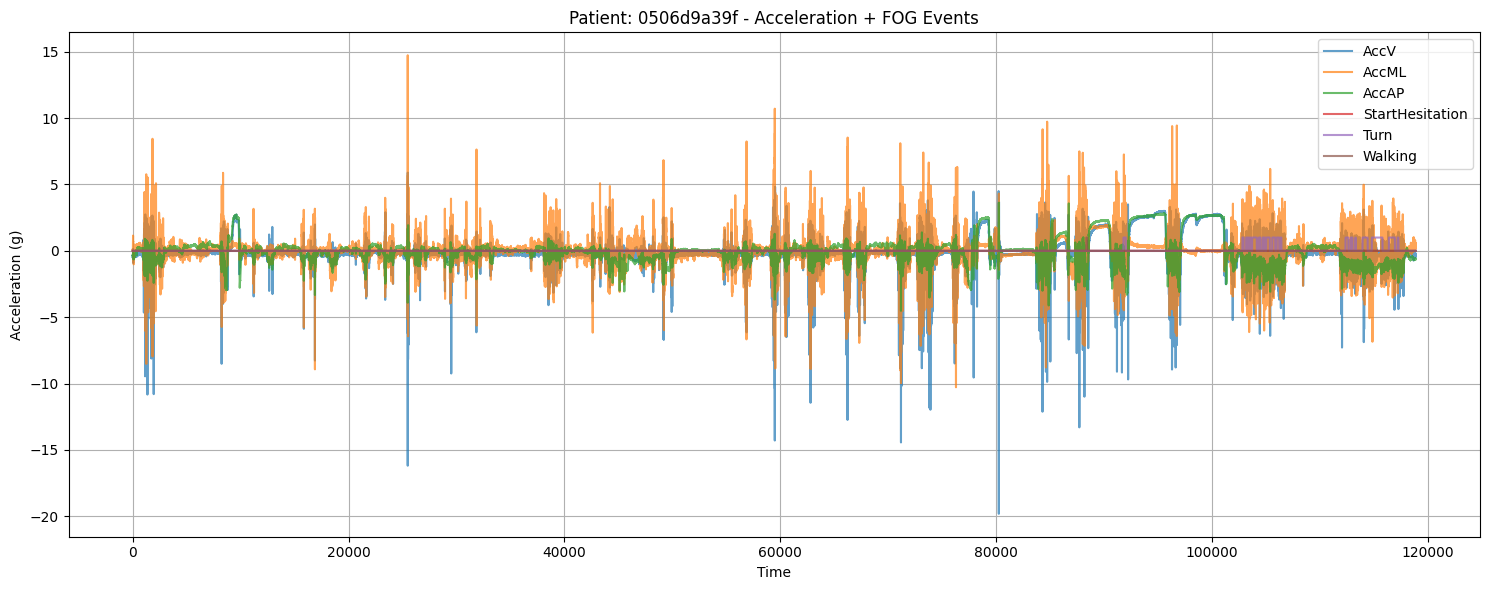

In [146]:
# 1. Filter your Polars DF for a single patient and convert to pandas
df = defog_df.filter(pl.col("patient_id") == 'be9d33541d').to_pandas()

# 2. Plot
plt.figure(figsize=(15, 6))

# Plot acceleration
plt.plot(df['Time'], df['AccV'], label='AccV', alpha=0.7)
plt.plot(df['Time'], df['AccML'], label='AccML', alpha=0.7)
plt.plot(df['Time'], df['AccAP'], label='AccAP', alpha=0.7)

# 3. Plot events
plt.plot(df['Time'], df['StartHesitation'], label='StartHesitation', alpha=0.7)
plt.plot(df['Time'], df['Turn'], label='Turn', alpha=0.7)
plt.plot(df['Time'], df['Walking'], label='Walking', alpha=0.7)


# 4. Final touches
plt.xlabel("Time")
plt.ylabel("Acceleration (g)")
plt.title(f"Patient: {patient_id} - Acceleration + FOG Events")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Data Cleaning

In [110]:
# Data types of features 
print(f'DEFOG DATA TYPES:\n{defog_df.dtypes}\n')
print(f'TDCSFOG DATA TYPES:\n{tdcsfog_df.dtypes}\n')

DEFOG DATA TYPES:
[Int64, Float64, Float64, Float64, Int64, Int64, Int64, Boolean, Boolean, String]

TDCSFOG DATA TYPES:
[Int64, Float64, Float64, Float64, Int64, Int64, Int64, String]



In [111]:
print(tdcsfog_df.null_count())

shape: (1, 8)
┌──────┬──────┬───────┬───────┬─────────────────┬──────┬─────────┬────────────┐
│ Time ┆ AccV ┆ AccML ┆ AccAP ┆ StartHesitation ┆ Turn ┆ Walking ┆ patient_id │
│ ---  ┆ ---  ┆ ---   ┆ ---   ┆ ---             ┆ ---  ┆ ---     ┆ ---        │
│ u32  ┆ u32  ┆ u32   ┆ u32   ┆ u32             ┆ u32  ┆ u32     ┆ u32        │
╞══════╪══════╪═══════╪═══════╪═════════════════╪══════╪═════════╪════════════╡
│ 0    ┆ 0    ┆ 0     ┆ 0     ┆ 0               ┆ 0    ┆ 0       ┆ 0          │
└──────┴──────┴───────┴───────┴─────────────────┴──────┴─────────┴────────────┘


In [112]:
# Convert accerlations in defog to m/s^2
G_CONVERSION = 9.80665
defog_df[["AccV", "AccML", "AccAP"]] *= G_CONVERSION
print(defog_df)

shape: (13_525_702, 10)
┌────────┬───────────┬──────────┬───────────┬───┬─────────┬───────┬───────┬────────────┐
│ Time   ┆ AccV      ┆ AccML    ┆ AccAP     ┆ … ┆ Walking ┆ Valid ┆ Task  ┆ patient_id │
│ ---    ┆ ---       ┆ ---      ┆ ---       ┆   ┆ ---     ┆ ---   ┆ ---   ┆ ---        │
│ i64    ┆ f64       ┆ f64      ┆ f64       ┆   ┆ i64     ┆ bool  ┆ bool  ┆ str        │
╞════════╪═══════════╪══════════╪═══════════╪═══╪═════════╪═══════╪═══════╪════════════╡
│ 0      ┆ -9.833101 ┆ 0.219382 ┆ 0.669832  ┆ … ┆ 0       ┆ false ┆ false ┆ be9d33541d │
│ 1      ┆ -9.832554 ┆ 0.188024 ┆ 0.648829  ┆ … ┆ 0       ┆ false ┆ false ┆ be9d33541d │
│ 2      ┆ -9.804885 ┆ 0.187721 ┆ 0.662298  ┆ … ┆ 0       ┆ false ┆ false ┆ be9d33541d │
│ 3      ┆ -9.787264 ┆ 0.180227 ┆ 0.670866  ┆ … ┆ 0       ┆ false ┆ false ┆ be9d33541d │
│ 4      ┆ -9.790555 ┆ 0.164025 ┆ 0.651633  ┆ … ┆ 0       ┆ false ┆ false ┆ be9d33541d │
│ …      ┆ …         ┆ …        ┆ …         ┆ … ┆ …       ┆ …     ┆ …     ┆ …         

In [113]:
# Convert the Valid and Task Columns to Integer Columns
def convert_valid_and_t(df):
    df = df.with_columns(
        pl.col("Valid").cast(pl.Int8).alias("Valid")
    )
    
    df = df.with_columns(
        pl.col("Task").cast(pl.Int8).alias("Task")
    )
    return df
defog_df = convert_valid_and_t(defog_df)
# tdcsfog_df = convert_valid_and_t(tdcsfog_df)


print(defog_df)

shape: (13_525_702, 10)
┌────────┬───────────┬──────────┬───────────┬───┬─────────┬───────┬──────┬────────────┐
│ Time   ┆ AccV      ┆ AccML    ┆ AccAP     ┆ … ┆ Walking ┆ Valid ┆ Task ┆ patient_id │
│ ---    ┆ ---       ┆ ---      ┆ ---       ┆   ┆ ---     ┆ ---   ┆ ---  ┆ ---        │
│ i64    ┆ f64       ┆ f64      ┆ f64       ┆   ┆ i64     ┆ i8    ┆ i8   ┆ str        │
╞════════╪═══════════╪══════════╪═══════════╪═══╪═════════╪═══════╪══════╪════════════╡
│ 0      ┆ -9.833101 ┆ 0.219382 ┆ 0.669832  ┆ … ┆ 0       ┆ 0     ┆ 0    ┆ be9d33541d │
│ 1      ┆ -9.832554 ┆ 0.188024 ┆ 0.648829  ┆ … ┆ 0       ┆ 0     ┆ 0    ┆ be9d33541d │
│ 2      ┆ -9.804885 ┆ 0.187721 ┆ 0.662298  ┆ … ┆ 0       ┆ 0     ┆ 0    ┆ be9d33541d │
│ 3      ┆ -9.787264 ┆ 0.180227 ┆ 0.670866  ┆ … ┆ 0       ┆ 0     ┆ 0    ┆ be9d33541d │
│ 4      ┆ -9.790555 ┆ 0.164025 ┆ 0.651633  ┆ … ┆ 0       ┆ 0     ┆ 0    ┆ be9d33541d │
│ …      ┆ …         ┆ …        ┆ …         ┆ … ┆ …       ┆ …     ┆ …    ┆ …          │
│ 109120

In [114]:
# Create a new column that contains the acceleration magnitude
def acc_magnitude(df):
    df = df.with_columns(
        (
            (pl.col("AccV") ** 2 + pl.col("AccML") ** 2 + pl.col("AccAP") ** 2).sqrt()
        ).alias("Acc_MAGNITUDE")
    )

    return df

tdcsfog_df = acc_magnitude(tdcsfog_df)
defog_df = acc_magnitude(defog_df)
defog_df

Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Valid,Task,patient_id,Acc_MAGNITUDE
i64,f64,f64,f64,i64,i64,i64,i8,i8,str,f64
0,-9.833101,0.219382,0.669832,0,0,0,0,0,"""be9d33541d""",9.85833
1,-9.832554,0.188024,0.648829,0,0,0,0,0,"""be9d33541d""",9.855732
2,-9.804885,0.187721,0.662298,0,0,0,0,0,"""be9d33541d""",9.829021
3,-9.787264,0.180227,0.670866,0,0,0,0,0,"""be9d33541d""",9.811885
4,-9.790555,0.164025,0.651633,0,0,0,0,0,"""be9d33541d""",9.813587
…,…,…,…,…,…,…,…,…,…,…
109120,-9.210807,0.30954,-3.871049,0,0,0,0,0,"""06414383cf""",9.99599
109121,-9.228995,0.309714,-3.850343,0,0,0,0,0,"""06414383cf""",10.004769
109122,-9.219534,0.285297,-3.867594,0,0,0,0,0,"""06414383cf""",10.001974


In [116]:
# Standardize acceleration per patient for each training dataframe
def standardize_acc_by_patient(df: pl.DataFrame):
    acc_cols = ['AccV', 'AccML', 'AccAP']
    for col in acc_cols:
        df = df.with_columns(
            (
                (pl.col(col) - pl.col(col).mean().over("patient_id")) /
                pl.col(col).std().over("patient_id")
            ).alias(col)  # overwrite original column
        )
    return df

In [120]:
# Band-pass Filter 
def infer_fs(time_seconds: np.ndarray) -> float:
    dt = np.diff(np.asarray(time_seconds, dtype=float))
    dt = dt[np.isfinite(dt) & (dt > 0)]
    if dt.size == 0:
        raise ValueError("Cannot infer sampling frequency from Time column.")
    return 1.0 / np.median(dt)

def design_bandpass(low_hz: float, high_hz: float, fs: float, order: int = 4):
    nyq = fs / 2.0
    low = max(1e-6, low_hz / nyq)
    high = min(0.999999, high_hz / nyq)
    if not (0 < low < high < 1):
        raise ValueError(f"Invalid band for fs={fs:.3f}Hz: low={low_hz}Hz, high={high_hz}Hz")
    b, a = butter(order, [low, high], btype="band")
    return b, a

def bandpass_series(y: pd.Series, b, a) -> np.ndarray:
    sig = pd.to_numeric(y, errors="coerce").interpolate(limit_direction="both").to_numpy(float)
    return filtfilt(b, a, sig, method="pad")

def bandpass_dataframe(df: pd.DataFrame, cols=('AccV','AccML','AccAP'),
                       low_hz=0.1, high_hz=30.0, order=4) -> pd.DataFrame:
    out = df.copy()
    # Only keep columns that exist
    cols = tuple([c for c in cols if c in out.columns])
    if len(cols) == 0:
        return out

    fs = infer_fs(out['Time'].to_numpy())
    b, a = design_bandpass(low_hz, high_hz, fs, order)
    for col in cols:
        out[f"{col}_bp"] = bandpass_series(out[col], b, a)
    return out



In [121]:
# Apply Band-pass to all patients 
def add_bandpass_to_all_patients(pl_df: pl.DataFrame,
                                 cols=('AccV','AccML','AccAP'),
                                 low_hz=0.1, high_hz=30.0, order=4) -> pl.DataFrame:
    if "patient_id" not in pl_df.columns:
        raise ValueError("Expected a 'patient_id' column.")

    out_chunks = []
    # Unique patient list
    patient_ids = pl_df.select("patient_id").unique().to_series().to_list()

    for pid in patient_ids:
        g = pl_df.filter(pl.col("patient_id") == pid).to_pandas()
        # Skip tiny or malformed groups
        if "Time" not in g.columns or len(g) < 5:
            out_chunks.append(pl.from_pandas(g))  # just pass through
            continue

        try:
            g_bp = bandpass_dataframe(g, cols=cols, low_hz=low_hz, high_hz=high_hz, order=order)
        except Exception as e:
            print(f"[WARN] Skipping bandpass for patient {pid}: {e}")
            g_bp = g  # pass through raw if something fails

        out_chunks.append(pl.from_pandas(g_bp))

    return pl.concat(out_chunks, how="vertical_relaxed")

defog_df_bp   = add_bandpass_to_all_patients(defog_df,   cols=('AccV','AccML','AccAP'),
                                             low_hz=0.1, high_hz=30.0, order=4)
tdcsfog_df_bp = add_bandpass_to_all_patients(tdcsfog_df, cols=('AccV','AccML','AccAP'),
                                             low_hz=0.1, high_hz=30.0, order=4)

print("DEFOG with band-pass columns:", [c for c in defog_df_bp.columns if c.endswith("_bp")][:6], "...")
print("TDCSFOG with band-pass columns:", [c for c in tdcsfog_df_bp.columns if c.endswith("_bp")][:6], "...")

DEFOG with band-pass columns: ['AccV_bp', 'AccML_bp', 'AccAP_bp'] ...
TDCSFOG with band-pass columns: ['AccV_bp', 'AccML_bp', 'AccAP_bp'] ...


In [122]:
tdcsfog_df = standardize_acc_by_patient(tdcsfog_df)
defog_df = standardize_acc_by_patient(defog_df)
defog_df

Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Valid,Task,patient_id,Acc_MAGNITUDE
i64,f64,f64,f64,i64,i64,i64,i8,i8,str,f64
0,-0.375372,0.093954,-0.32069,0,0,0,0,0,"""be9d33541d""",9.85833
1,-0.374921,0.053599,-0.329435,0,0,0,0,0,"""be9d33541d""",9.855732
2,-0.352097,0.053208,-0.323827,0,0,0,0,0,"""be9d33541d""",9.829021
3,-0.337562,0.043565,-0.32026,0,0,0,0,0,"""be9d33541d""",9.811885
4,-0.340277,0.022714,-0.328268,0,0,0,0,0,"""be9d33541d""",9.813587
…,…,…,…,…,…,…,…,…,…,…
109120,0.108433,0.126815,-0.645129,0,0,0,0,0,"""06414383cf""",9.99599
109121,0.078984,0.12706,-0.6384,0,0,0,0,0,"""06414383cf""",10.004769
109122,0.094303,0.092946,-0.644006,0,0,0,0,0,"""06414383cf""",10.001974


In [127]:
print(defog_df_bp.columns)


['Time', 'AccV', 'AccML', 'AccAP', 'StartHesitation', 'Turn', 'Walking', 'Valid', 'Task', 'patient_id', 'Acc_MAGNITUDE', 'AccV_bp', 'AccML_bp', 'AccAP_bp']


In [128]:
df_check = defog_df_bp.filter(pl.col("patient_id")=="4c3aa8ea6e").to_pandas()
print(df_check[["AccV_bp","AccML_bp","AccAP_bp"]].head())
print(df_check[["AccV_bp","AccML_bp","AccAP_bp"]].isna().sum())

     AccV_bp  AccML_bp  AccAP_bp
0 -25.769859 -0.066453 -0.047719
1  25.769769  0.120982  0.112273
2 -25.767956 -0.043733 -0.002046
3  25.769013  0.069846  0.091353
4 -25.767079 -0.068549 -0.019001
AccV_bp     0
AccML_bp    0
AccAP_bp    0
dtype: int64


In [129]:
# Re-run bandpass step, capture warnings
defog_df_bp = add_bandpass_to_all_patients(
    defog_df,
    cols=('AccV','AccML','AccAP'),
    low_hz=0.1, high_hz=30.0, order=4
)

In [130]:
defog_df_bp.select(
    pl.col("AccV_bp").count(),
    pl.col("AccML_bp").count(),
    pl.col("AccAP_bp").count()
)

AccV_bp,AccML_bp,AccAP_bp
u32,u32,u32
13525702,13525702,13525702


# Plot Magnitude 

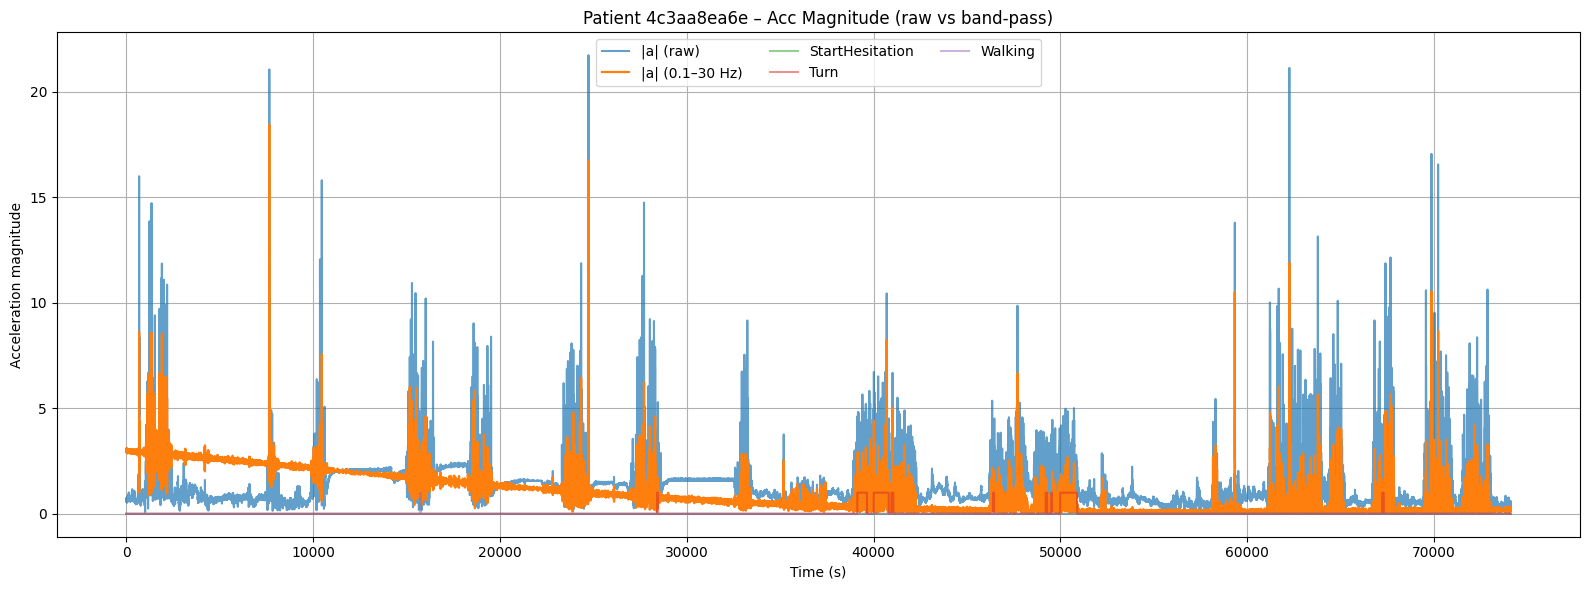

In [131]:
def add_magnitude_cols(pl_df: pl.DataFrame) -> pl.DataFrame: 
    out = pl_df.with_columns(
        ((pl.col("AccV")**2 + pl.col("AccML")**2 + pl.col("AccAP")**2).sqrt()).alias("AccMag")
    )
    bp_cols = {"AccV_bp", "AccML_bp", "AccAP_bp"}
    if bp_cols.issubset(set(out.columns)):
        out = out.with_columns(
            ((pl.col("AccV_bp")**2 + pl.col("AccML_bp")**2 + pl.col("AccAP_bp")**2).sqrt()).alias("AccMag_bp")
        )
    return out 
    
def plot_patient_mag(pl_df: pl.DataFrame, patient_id: str,
                     time_col: str = "Time",
                     show_events: bool = True,
                     title_suffix: str = ""):
    dfp = pl_df.filter(pl.col("patient_id") == patient_id).to_pandas()
    if not {"AccMag", time_col}.issubset(dfp.columns):
        raise ValueError("Missing magnitude or time column")
    plt.figure(figsize=(16,6))
    plt.plot(dfp[time_col], dfp["AccMag"], label="|a| (raw)", alpha=0.7)
    if "AccMag_bp" in dfp.columns:
        plt.plot(dfp[time_col], dfp["AccMag_bp"], label="|a| (0.1–30 Hz)", linewidth=1.6)
    if show_events:
        for ev in ["StartHesitation", "Turn", "Walking"]:
            if ev in dfp.columns:
                plt.plot(dfp[time_col], dfp[ev], label=ev, alpha=0.5)
    plt.xlabel("Time (s)")
    plt.ylabel("Acceleration magnitude")
    plt.title(f"Patient {patient_id} – Acc Magnitude {title_suffix}")
    plt.legend(ncol=3)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Add magnitude columns to dataframes
defog_df_bp = add_magnitude_cols(defog_df_bp)
tdcsfog_df_bp = add_magnitude_cols(tdcsfog_df_bp)
defog_df = add_magnitude_cols(defog_df)
tdcsfog_df = add_magnitude_cols(tdcsfog_df)

# Plot magnitude for one patient
plot_patient_mag(defog_df_bp, patient_id="4c3aa8ea6e", title_suffix="(raw vs band-pass)")


In [132]:
# Create a new column that contains Time as seconds
def time_to_seconds(df, hertz):
    df = df.with_columns(
        (
            (pl.col("Time") / hertz)
        ).alias("Time (seconds)")
    )

    return df

tdcsfog_df = time_to_seconds(tdcsfog_df, 128)
defog_df = time_to_seconds(defog_df, 100)
defog_df

Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Valid,Task,patient_id,Acc_MAGNITUDE,AccMag,Time (seconds)
i64,f64,f64,f64,i64,i64,i64,i8,i8,str,f64,f64,f64
0,-0.375372,0.093954,-0.32069,0,0,0,0,0,"""be9d33541d""",9.85833,0.502567,0.0
1,-0.374921,0.053599,-0.329435,0,0,0,0,0,"""be9d33541d""",9.855732,0.501963,0.01
2,-0.352097,0.053208,-0.323827,0,0,0,0,0,"""be9d33541d""",9.829021,0.481319,0.02
3,-0.337562,0.043565,-0.32026,0,0,0,0,0,"""be9d33541d""",9.811885,0.467346,0.03
4,-0.340277,0.022714,-0.328268,0,0,0,0,0,"""be9d33541d""",9.813587,0.473354,0.04
…,…,…,…,…,…,…,…,…,…,…,…,…
109120,0.108433,0.126815,-0.645129,0,0,0,0,0,"""06414383cf""",9.99599,0.666357,1091.2
109121,0.078984,0.12706,-0.6384,0,0,0,0,0,"""06414383cf""",10.004769,0.655696,1091.21
109122,0.094303,0.092946,-0.644006,0,0,0,0,0,"""06414383cf""",10.001974,0.657477,1091.22


In [133]:
# Check for outliers from acceleration
def detect_outliers(df: pl.DataFrame):
    acc_cols = ['AccV', 'AccML', 'AccAP']
    for col in acc_cols: 
        z_col = col
        outlier_df = df.filter(pl.col(z_col).abs() > 3.0)
    return outlier_df
print(detect_outliers(defog_df))
print(detect_outliers(tdcsfog_df))

shape: (77_505, 13)
┌────────┬───────────┬───────────┬───────────┬───┬────────────┬────────────┬───────────┬───────────┐
│ Time   ┆ AccV      ┆ AccML     ┆ AccAP     ┆ … ┆ patient_id ┆ Acc_MAGNIT ┆ AccMag    ┆ Time      │
│ ---    ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---        ┆ UDE        ┆ ---       ┆ (seconds) │
│ i64    ┆ f64       ┆ f64       ┆ f64       ┆   ┆ str        ┆ ---        ┆ f64       ┆ ---       │
│        ┆           ┆           ┆           ┆   ┆            ┆ f64        ┆           ┆ f64       │
╞════════╪═══════════╪═══════════╪═══════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
│ 16882  ┆ -4.975115 ┆ -4.733771 ┆ -3.195526 ┆ … ┆ be9d33541d ┆ 16.993968  ┆ 7.574414  ┆ 168.82    │
│ 16883  ┆ -8.26779  ┆ -8.931648 ┆ -3.331027 ┆ … ┆ be9d33541d ┆ 21.577567  ┆ 12.618496 ┆ 168.83    │
│ 25478  ┆ 0.887827  ┆ -1.717834 ┆ -3.90909  ┆ … ┆ be9d33541d ┆ 11.554851  ┆ 4.361213  ┆ 254.78    │
│ 25479  ┆ -6.81384  ┆ 3.323583  ┆ -3.248141 ┆ … ┆ be9d33541d ┆ 18.9479

## Visualize Acceleration  Signals During FoG Events

In [135]:
# Get unique patient IDs with a StartHesitation, Turn, and Walking event
# Take a subset of 3 patients for each event
StartHesPatients = (
    defog_df.filter(pl.col("StartHesitation") == 1)
            .select("patient_id")
            .unique()
            .to_series()[:3]  # take first 3
)
print(f"Patients with Start Hesitation: {StartHesPatients.to_list()}")

TurnPatients = (
    defog_df.filter(pl.col("Turn") == 1)
            .select("patient_id")
            .unique()
            .to_series()[:3]
)
print(f"Patients with Turn: {TurnPatients.to_list()}")

WalkingPatients = (
    defog_df.filter(pl.col("Walking") == 1)
            .select("patient_id")
            .unique()
            .to_series()[:3]
)
print(f"Patients with Walking: {WalkingPatients.to_list()}")

Patients with Start Hesitation: ['68e7e02a47', 'e069a57511', '77d7d95074']
Patients with Turn: ['0c55be4384', '2c12284ed2', '18e7abc37e']
Patients with Walking: ['5327e062c9', '8db3a7e46b', '32d03020a9']


In [137]:
# Get unique patient IDs with a StartHesitation, Turn, and Walking event 
# (including band-pass)
if {"StartHesitation","Turn","Walking"}.issubset(set(defog_df_bp.columns)):
    StartHesPatients = (
        defog_df_bp.filter(pl.col("StartHesitation") == 1)
                   .select("patient_id").unique().to_series()[:3]
    )
    TurnPatients = (
        defog_df_bp.filter(pl.col("Turn") == 1)
                   .select("patient_id").unique().to_series()[:3]
    )
    WalkingPatients = (
        defog_df_bp.filter(pl.col("Walking") == 1)
                   .select("patient_id").unique().to_series()[:3]
    )
    print(f"Patients with Start Hesitation: {StartHesPatients.to_list()}")
    print(f"Patients with Turn: {TurnPatients.to_list()}")
    print(f"Patients with Walking: {WalkingPatients.to_list()}")

Patients with Start Hesitation: ['1d99c2eecf', '8282009100', 'bf2fd0ff35']
Patients with Turn: ['1ff78d55e9', '0ec76d2d8e', '8d2d863dfd']
Patients with Walking: ['139f60d29b', '3f3b08f78d', '092b4c1819']


In [154]:
pid = "81262644e7"

df = tdcsfog_df.filter(pl.col("patient_id") == pid).to_pandas()

# Verify
print("Rows:", df.shape)

Rows: (10031, 11)


In [159]:
events = events_df[events_df["Id"] == pid].copy()

if len(events) == 0:
    print("⚠️ No events found for this patient")
else:
    events["event_start_s"] = events["Init"]
    events["event_end_s"]   = events["Completion"]

    print(events[["Type","event_start_s","event_end_s"]].head())

                Type  event_start_s  event_end_s
529  StartHesitation        5.43281      7.95281
530             Turn       11.71280     28.31280
531             Turn       34.55280     36.99280
532  StartHesitation       44.15280     47.85280
533          Walking       53.57280     55.73280


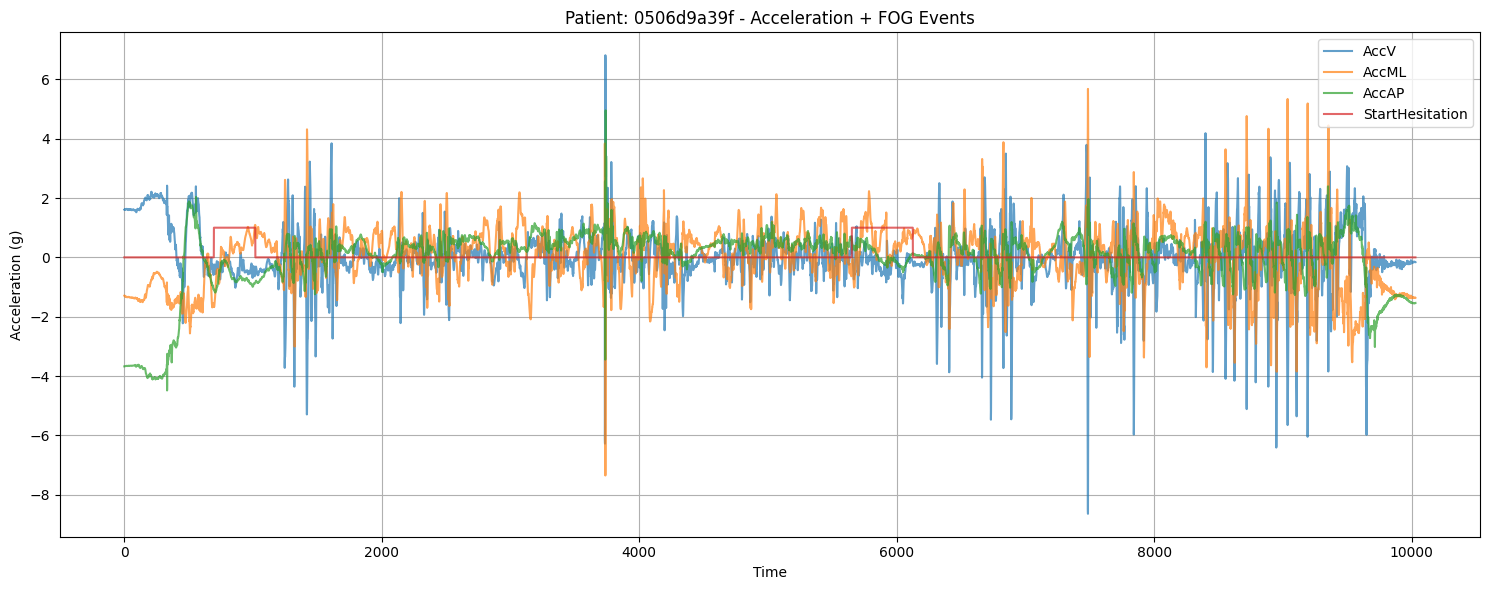

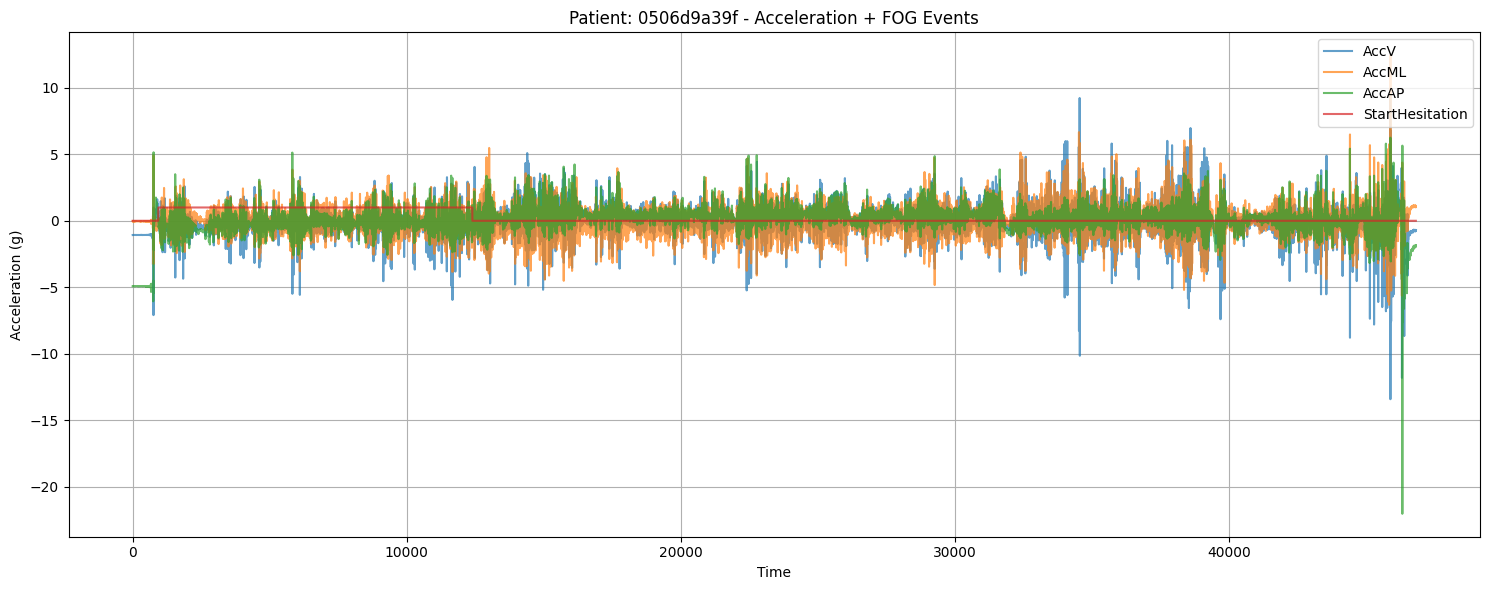

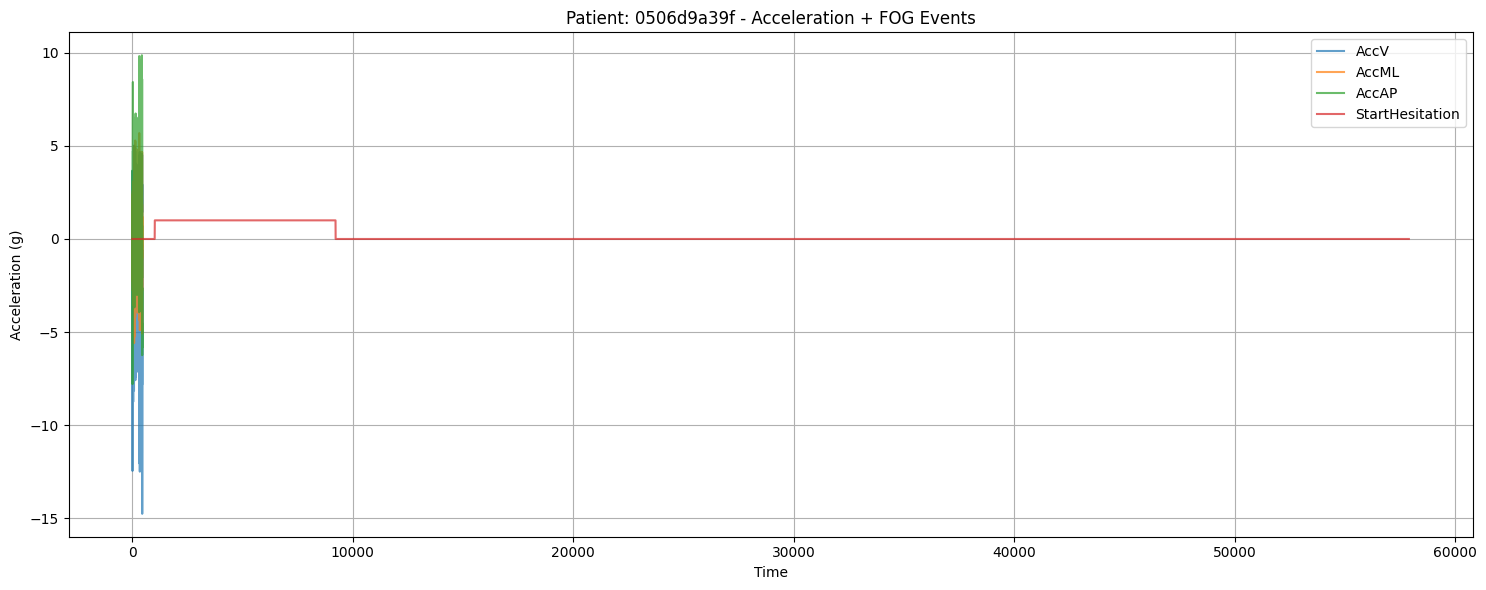

In [161]:
# Start Hestitation
# 1. Filter Polars DF for a single patient and convert to pandas
df = tdcsfog_df.filter(pl.col("patient_id") == '81262644e7').to_pandas()

# 2. Plot
plt.figure(figsize=(15, 6))

# Plot acceleration
plt.plot(df['Time'], df['AccV'], label='AccV', alpha=0.7)
plt.plot(df['Time'], df['AccML'], label='AccML', alpha=0.7)
plt.plot(df['Time'], df['AccAP'], label='AccAP', alpha=0.7)

# 3. Plot events
plt.plot(df['Time'], df['StartHesitation'], label='StartHesitation', alpha=0.7)


# 4. Final touches
plt.xlabel("Time")
plt.ylabel("Acceleration (g)")
plt.title(f"Patient: {patient_id} - Acceleration + FOG Events")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()


# Start Hestitation
# 1. Filter your Polars DF for a single patient and convert to pandas
df = tdcsfog_df.filter(pl.col("patient_id") == '3ba3590a08').to_pandas()

# 2. Plot
plt.figure(figsize=(15, 6))

# Plot acceleration
plt.plot(df['Time'], df['AccV'], label='AccV', alpha=0.7)
plt.plot(df['Time'], df['AccML'], label='AccML', alpha=0.7)
plt.plot(df['Time'], df['AccAP'], label='AccAP', alpha=0.7)

# 3. Plot events
plt.plot(df['Time'], df['StartHesitation'], label='StartHesitation', alpha=0.7)


# 4. Final touches
plt.xlabel("Time")
plt.ylabel("Acceleration (g)")
plt.title(f"Patient: {patient_id} - Acceleration + FOG Events")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()



# Start Hestitation
# 1. Filter your Polars DF for a single patient and convert to pandas
df = tdcsfog_df.filter(pl.col("patient_id") == 'd98358a75f').to_pandas()

# 2. Plot
plt.figure(figsize=(15, 6))

# Plot acceleration
plt.plot(df['Time (seconds)'], df['AccV'], label='AccV', alpha=0.7)
plt.plot(df['Time (seconds)'], df['AccML'], label='AccML', alpha=0.7)
plt.plot(df['Time (seconds)'], df['AccAP'], label='AccAP', alpha=0.7)

# 3. Plot events
plt.plot(df['Time'], df['StartHesitation'], label='StartHesitation', alpha=0.7)


# 4. Final touches
plt.xlabel("Time")
plt.ylabel("Acceleration (g)")
plt.title(f"Patient: {patient_id} - Acceleration + FOG Events")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Extract Time Domain Features 

In [28]:
def tdcsfog_time_features_pl(df: pl.DataFrame, fs: float = 128.0, win_s: float = 2.0, hop_s: float = 0.5) -> pl.DataFrame:
    """
    Extract time-domain features from accelerometer data.
    """

    # --- column detection ---
    cols = df.columns
    lower = {c.lower(): c for c in cols}
    candidates = [
        ['AccX','AccY','AccZ'],
        ['AccelX','AccelY','AccelZ'],
        ['acc_x','acc_y','acc_z'],
        ['AccV','AccML','AccAP'],
        ['accv','accml','accap'],
    ]
    acc_cols = None
    for trio in candidates:
        found = [lower.get(c.lower()) for c in trio]
        if all(found):
            acc_cols = found
            break
    if acc_cols is None:
        acc_cols = [c for c in cols if "acc" in c.lower()][:3]
    if len(acc_cols) < 3:
        raise KeyError(f"Could not find 3 accelerometer columns. Found: {acc_cols}")

    label_cols = [c for c in ['StartHesitation','Turn','Walking'] if c in cols]

    # --- setup ---
    n = df.height
    win = int(round(fs * win_s))
    hop = int(round(fs * hop_s))

    X = df.select(acc_cols).to_numpy()
    labels = df.select(label_cols).to_numpy() if label_cols else None

    rows = []
    win_id = 0

    # --- sliding windows ---
    for start in range(0, n - win + 1, hop):
        end = start + win
        W = X[start:end, :]
        f = {}

        for i, c in enumerate(acc_cols):
            w = W[:, i]
            f[f'{c}_mean'] = float(np.nanmean(w))
            f[f'{c}_std'] = float(np.nanstd(w))
            f[f'{c}_var'] = float(np.nanvar(w))
            f[f'{c}_min'] = float(np.nanmin(w))
            f[f'{c}_max'] = float(np.nanmax(w))
            f[f'{c}_median'] = float(np.nanmedian(w))
            q75, q25 = np.nanpercentile(w, [75, 25])
            f[f'{c}_iqr'] = float(q75 - q25)
            f[f'{c}_energy'] = float(np.nansum(w**2) / len(w))
            f[f'{c}_rms'] = float(np.sqrt(np.nanmean(w**2)))
            if np.nanstd(w) > 0:
                f[f'{c}_skew'] = float(((w - np.nanmean(w))**3).mean() / (np.nanstd(w)**3))
                f[f'{c}_kurt'] = float(((w - np.nanmean(w))**4).mean() / (np.nanstd(w)**4) - 3)
            else:
                f[f'{c}_skew'] = np.nan
                f[f'{c}_kurt'] = np.nan

        # magnitude & SMA
        mag = np.sqrt(np.sum(W**2, axis=1))
        f['Acc_mag_mean'] = float(np.nanmean(mag))
        f['Acc_mag_std'] = float(np.nanstd(mag))
        f['Acc_sma'] = float(np.nansum(np.abs(W)) / len(W))

        # correlations
        def corr_safe(a, b):
            if np.nanstd(a) == 0 or np.nanstd(b) == 0:
                return np.nan
            return np.corrcoef(a, b)[0, 1]
        f[f'corr_{acc_cols[0]}_{acc_cols[1]}'] = corr_safe(W[:,0], W[:,1])
        f[f'corr_{acc_cols[0]}_{acc_cols[2]}'] = corr_safe(W[:,0], W[:,2])
        f[f'corr_{acc_cols[1]}_{acc_cols[2]}'] = corr_safe(W[:,1], W[:,2])

        # label flags
        if labels is not None:
            sub = labels[start:end, :]
            f['label_any'] = bool((sub > 0).any())
            for j, c in enumerate(label_cols):
                f[f'label_{c}'] = bool((sub[:, j] > 0).any())

        # metadata
        f['win_id'] = win_id
        f['t_start_s'] = start / fs
        f['t_end_s'] = (end - 1) / fs

        rows.append(f)
        win_id += 1

    return pl.DataFrame(rows)


In [29]:
FS = 128.0
WIN = 2.0
HOP = 0.5

tdcsfog_feats = tdcsfog_time_features_pl(tdcsfog_df, fs=FS, win_s=WIN, hop_s=HOP)
print(tdcsfog_feats.head())

shape: (5, 46)
┌───────────┬──────────┬──────────┬───────────┬───┬───────────────┬────────┬───────────┬───────────┐
│ AccV_mean ┆ AccV_std ┆ AccV_var ┆ AccV_min  ┆ … ┆ label_Walking ┆ win_id ┆ t_start_s ┆ t_end_s   │
│ ---       ┆ ---      ┆ ---      ┆ ---       ┆   ┆ ---           ┆ ---    ┆ ---       ┆ ---       │
│ f64       ┆ f64      ┆ f64      ┆ f64       ┆   ┆ bool          ┆ i64    ┆ f64       ┆ f64       │
╞═══════════╪══════════╪══════════╪═══════════╪═══╪═══════════════╪════════╪═══════════╪═══════════╡
│ -0.091689 ┆ 0.004893 ┆ 0.000024 ┆ -0.105169 ┆ … ┆ false         ┆ 0      ┆ 0.0       ┆ 1.9921875 │
│ -0.091683 ┆ 0.00494  ┆ 0.000024 ┆ -0.105169 ┆ … ┆ false         ┆ 1      ┆ 0.5       ┆ 2.4921875 │
│ -0.091384 ┆ 0.004792 ┆ 0.000023 ┆ -0.104503 ┆ … ┆ false         ┆ 2      ┆ 1.0       ┆ 2.9921875 │
│ -0.092139 ┆ 0.004843 ┆ 0.000023 ┆ -0.104503 ┆ … ┆ false         ┆ 3      ┆ 1.5       ┆ 3.4921875 │
│ -0.093149 ┆ 0.004516 ┆ 0.00002  ┆ -0.104503 ┆ … ┆ false         ┆ 4      ┆

In [30]:
tdcsfog_feats.shape

(110351, 46)

Add mid-time 
- Add t_center_s so all feature labels share the same key 

In [31]:
def tdcsfog_time_features_pl(df: pl.DataFrame, fs: float = 128.0, win_s: float = 2.0, hop_s: float = 0.5) -> pl.DataFrame:
    """
    Extract time-domain features from accelerometer data.
    """

    # column detection
    cols = df.columns
    lower = {c.lower(): c for c in cols}
    candidates = [
        ['AccX','AccY','AccZ'],
        ['AccelX','AccelY','AccelZ'],
        ['acc_x','acc_y','acc_z'],
        ['AccV','AccML','AccAP'],
        ['accv','accml','accap'],
    ]
    acc_cols = None
    for trio in candidates:
        found = [lower.get(c.lower()) for c in trio]
        if all(found):
            acc_cols = found
            break
    if acc_cols is None:
        acc_cols = [c for c in cols if "acc" in c.lower()][:3]
    if len(acc_cols) < 3:
        raise KeyError(f"Could not find 3 accelerometer columns. Found: {acc_cols}")

    label_cols = [c for c in ['StartHesitation','Turn','Walking'] if c in cols]

    # setup 
    n = df.height
    win = int(round(fs * win_s))
    hop = int(round(fs * hop_s))

    X = df.select(acc_cols).to_numpy()
    labels = df.select(label_cols).to_numpy() if label_cols else None

    rows = []
    win_id = 0

    # sliding windows 
    for start in range(0, n - win + 1, hop):
        end = start + win
        W = X[start:end, :]
        f = {}

        for i, c in enumerate(acc_cols):
            w = W[:, i]
            f[f'{c}_mean'] = float(np.nanmean(w))
            f[f'{c}_std'] = float(np.nanstd(w))
            f[f'{c}_var'] = float(np.nanvar(w))
            f[f'{c}_min'] = float(np.nanmin(w))
            f[f'{c}_max'] = float(np.nanmax(w))
            f[f'{c}_median'] = float(np.nanmedian(w))
            q75, q25 = np.nanpercentile(w, [75, 25])
            f[f'{c}_iqr'] = float(q75 - q25)
            f[f'{c}_energy'] = float(np.nansum(w**2) / len(w))
            f[f'{c}_rms'] = float(np.sqrt(np.nanmean(w**2)))
            if np.nanstd(w) > 0:
                f[f'{c}_skew'] = float(((w - np.nanmean(w))**3).mean() / (np.nanstd(w)**3))
                f[f'{c}_kurt'] = float(((w - np.nanmean(w))**4).mean() / (np.nanstd(w)**4) - 3)
            else:
                f[f'{c}_skew'] = np.nan
                f[f'{c}_kurt'] = np.nan

        # magnitude & SMA
        mag = np.sqrt(np.sum(W**2, axis=1))
        f['Acc_mag_mean'] = float(np.nanmean(mag))
        f['Acc_mag_std'] = float(np.nanstd(mag))
        f['Acc_sma'] = float(np.nansum(np.abs(W)) / len(W))

        # correlations
        def corr_safe(a, b):
            if np.nanstd(a) == 0 or np.nanstd(b) == 0:
                return np.nan
            return np.corrcoef(a, b)[0, 1]
        f[f'corr_{acc_cols[0]}_{acc_cols[1]}'] = corr_safe(W[:,0], W[:,1])
        f[f'corr_{acc_cols[0]}_{acc_cols[2]}'] = corr_safe(W[:,0], W[:,2])
        f[f'corr_{acc_cols[1]}_{acc_cols[2]}'] = corr_safe(W[:,1], W[:,2])

        # label flags
        if labels is not None:
            sub = labels[start:end, :]
            f['label_any'] = bool((sub > 0).any())
            for j, c in enumerate(label_cols):
                f[f'label_{c}'] = bool((sub[:, j] > 0).any())

        # metadata – start, end, and mid time of the window (in seconds)
        f['win_id'] = win_id
        f['t_start_s'] = start / fs
        f['t_end_s'] = (end - 1) / fs
        f['t_center_s'] = (f['t_start_s'] + f['t_end_s']) / 2.0

        rows.append(f)
        win_id += 1

    return pl.DataFrame(rows)

Regenerate Time Domain Features (after updating function)


In [32]:
tdcsfog_feats = tdcsfog_time_features_pl(
    tdcsfog_df, 
    fs=FS, 
    win_s=WIN, 
    hop_s=HOP
)

print("Time feature columns:", tdcsfog_feats.columns)
print("Contains t_center_s:", "t_center_s" in tdcsfog_feats.columns)

Time feature columns: ['AccV_mean', 'AccV_std', 'AccV_var', 'AccV_min', 'AccV_max', 'AccV_median', 'AccV_iqr', 'AccV_energy', 'AccV_rms', 'AccV_skew', 'AccV_kurt', 'AccML_mean', 'AccML_std', 'AccML_var', 'AccML_min', 'AccML_max', 'AccML_median', 'AccML_iqr', 'AccML_energy', 'AccML_rms', 'AccML_skew', 'AccML_kurt', 'AccAP_mean', 'AccAP_std', 'AccAP_var', 'AccAP_min', 'AccAP_max', 'AccAP_median', 'AccAP_iqr', 'AccAP_energy', 'AccAP_rms', 'AccAP_skew', 'AccAP_kurt', 'Acc_mag_mean', 'Acc_mag_std', 'Acc_sma', 'corr_AccV_AccML', 'corr_AccV_AccAP', 'corr_AccML_AccAP', 'label_any', 'label_StartHesitation', 'label_Turn', 'label_Walking', 'win_id', 't_start_s', 't_end_s', 't_center_s']
Contains t_center_s: True


# Extract Frequency Domain Features 
*  The Fourier Transform is a mathematical tool that takes a complex signal and breaks it down into its individual frequency components. It tells us what frequencies make up the signal and how strong each one is.
*  Time Domain features (mean, std, min, max, variance, median) shoes how a signal changes over time while a frequency domain feature (domiant frequency, spectral enegy, PSD) shows what frequencies make up the signal and how fast or periodic the motion is.
*  This helps us analyze how the signal's energy is distrubuted across different frequencies, revealing rhytmic motion patterns like walking, turning, or freezing of gait.
*  For PSD, we utilized Welch's method which smooths the FFT to give a more stable estimate of singal power over frequency. It does a great job detaching dominant movement frequencies (like steps per second)

Manual Frequency Features: 
* Directly linked to Parkinson's biomarkers like tremor, gait frequency, and freezing index
* Ability to tweak freqency bands, window sizes, or filtering parameters
  Quick to compute for large datasets 

In [33]:
from scipy.fft import rfft, rfftfreq
from scipy.signal import welch

def extract_frequency_features_pl(
    df: pl.DataFrame, 
    fs: float = 128.0, 
    win_s: float = 2.0, 
    hop_s: float = 0.5,
    signal_cols: tuple = ('AccV', 'AccML', 'AccAP')
) -> pl.DataFrame:
    """
    Extract frequency-domain (spectrogram-like) features from Polars DataFrame.
    Computes band energies, walking/freezing ratios, and a freezing index.
    Each sliding window behaves like one time column of a spectrogram.
    """
    # Detect accelerometer columns
    cols = df.columns
    lower = {c.lower(): c for c in cols}
    candidates = [
        ['AccX','AccY','AccZ'],
        ['AccelX','AccelY','AccelZ'],
        ['acc_x','acc_y','acc_z'],
        ['AccV','AccML','AccAP'],
        ['accv','accml','accap'],
    ]
    acc_cols = None
    for trio in candidates:
        found = [lower.get(c.lower()) for c in trio]
        if all(found):
            acc_cols = found
            break
    if acc_cols is None:
        acc_cols = [c for c in cols if "acc" in c.lower()][:3]
    if len(acc_cols) < 3:
        raise KeyError(f"Could not find 3 accelerometer columns. Found: {acc_cols}")
    
    # Setup
    n = df.height
    win = int(round(fs * win_s))
    hop = int(round(fs * hop_s))
    X = df.select(acc_cols).to_numpy()
    
    rows = []
    win_id = 0
    eps = 1e-9
    
    for start in range(0, n - win + 1, hop):
        end = start + win
        segment = X[start:end, :]
        fdict = {}
        
        # Time metadata for this spectrogram column
        t_start_s = start / fs
        t_end_s = (end - 1) / fs
        t_center_s = (t_start_s + t_end_s) / 2.0
        
        for i, col in enumerate(acc_cols):
            sig = segment[:, i]
            sig = sig - np.nanmean(sig)
            sig = np.nan_to_num(sig)
            
            # PSD using Welch's method (spectral density vs frequency)
            f_psd, psd = welch(sig, fs=fs, nperseg=min(win, len(sig)))
            
            # Basic PSD stats
            fdict[f"{col}_psd_mean"] = float(np.mean(psd))
            fdict[f"{col}_psd_std"] = float(np.std(psd))
            fdict[f"{col}_psd_max"] = float(np.max(psd))
            fdict[f"{col}_dominant_freq"] = float(f_psd[np.argmax(psd)])
            
            # ---- Band definitions (in Hz) ----
            walking_band = (f_psd >= 0.5) & (f_psd < 3.0)   # gait band
            freezing_band = (f_psd >= 3.0) & (f_psd < 8.0)  # FoG band
            total_band = (f_psd >= 0.5) & (f_psd < 30.0)    # overall movement
            
            # Integrate PSD (area) → energy in each band
            walking_energy = np.trapz(psd[walking_band], f_psd[walking_band]) if walking_band.any() else 0.0
            freezing_energy = np.trapz(psd[freezing_band], f_psd[freezing_band]) if freezing_band.any() else 0.0
            total_energy = np.trapz(psd[total_band], f_psd[total_band]) if total_band.any() else 0.0
            
            # Save absolute energies
            fdict[f"{col}_walking_energy"] = float(walking_energy)
            fdict[f"{col}_freezing_energy"] = float(freezing_energy)
            fdict[f"{col}_total_energy"] = float(total_energy)
            
            # Ratios (these are your "spectrogram features")
            fdict[f"{col}_walking_energy_ratio"] = float(walking_energy / (total_energy + eps))
            fdict[f"{col}_freezing_energy_ratio"] = float(freezing_energy / (total_energy + eps))
            
            # Freezing index: spectral ratio between freezing and walking bands
            fdict[f"{col}_freezing_index"] = float(freezing_energy / (walking_energy + eps))
            
            # Spectral entropy (complexity)
            psd_norm = psd / (np.sum(psd) + eps)
            spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + eps))
            fdict[f"{col}_spectral_entropy"] = float(spectral_entropy)
        
        # Metadata
        fdict['win_id'] = win_id
        fdict['t_start_s'] = t_start_s
        fdict['t_end_s'] = t_end_s
        fdict['t_center_s'] = t_center_s
        
        rows.append(fdict)
        win_id += 1
    
    return pl.DataFrame(rows)

In [34]:
tdcsfog_feats.shape


(110351, 47)

# Using tsfresh 

**Frequency Domain: FFT coefficients, spectral entropy, energy ratios, etc.**
* Time domain: mean, variance, autocorrelation, absolute energy, quantiles, etc.
* Complex statistics: number of peaks, linear trend slopes, precentage of reoccuring datapoints, and more.
  
**that allows our model to**
* Capture hidden micro-patterns in gait that's not visibilly obvious
* Use automated feature selection later (tsfresh.select_features())
* Complement your domain-driven features with new, data-driven ones - something revealing new insights 

In [35]:
def extract_advanced_features_pl(
    df: pl.DataFrame,
    fs: float = 128.0,
    win_s: float = 2.0,
    hop_s: float = 0.5,
    signal_cols: tuple = ('AccV', 'AccML', 'AccAP')
) -> pl.DataFrame:
    """
    Extract advanced statistical features (tsfresh-like) from Polars DataFrame.
    Includes autocorrelation, complexity, peak detection, and more.
    """
    
    # Detect columns
    cols = df.columns
    lower = {c.lower(): c for c in cols}
    candidates = [
        ['AccX','AccY','AccZ'],
        ['AccelX','AccelY','AccelZ'],
        ['acc_x','acc_y','acc_z'],
        ['AccV','AccML','AccAP'],
        ['accv','accml','accap'],
    ]
    acc_cols = None
    for trio in candidates:
        found = [lower.get(c.lower()) for c in trio]
        if all(found):
            acc_cols = found
            break
    if acc_cols is None:
        acc_cols = [c for c in cols if "acc" in c.lower()][:3]
    
    # Setup
    n = df.height
    win = int(round(fs * win_s))
    hop = int(round(fs * hop_s))
    
    X = df.select(acc_cols).to_numpy()
    
    rows = []
    win_id = 0
    
    for start in range(0, n - win + 1, hop):
        end = start + win
        segment = X[start:end, :]
        fdict = {}
        
        for i, col in enumerate(acc_cols):
            sig = segment[:, i]
            sig = np.nan_to_num(sig)
            
            # Absolute energy
            fdict[f"{col}_abs_energy"] = float(np.sum(sig ** 2))
            
            # Absolute sum of changes
            fdict[f"{col}_abs_sum_changes"] = float(np.sum(np.abs(np.diff(sig))))
            
            # Autocorrelation (lag 1)
            if len(sig) > 1:
                sig_shifted = sig[1:]
                sig_orig = sig[:-1]
                if np.std(sig_orig) > 0 and np.std(sig_shifted) > 0:
                    autocorr = np.corrcoef(sig_orig, sig_shifted)[0, 1]
                else:
                    autocorr = 0.0
            else:
                autocorr = 0.0
            fdict[f"{col}_autocorr_lag1"] = float(autocorr)
            
            # Number of peaks (using simple threshold)
            mean_val = np.mean(sig)
            std_val = np.std(sig)
            threshold = mean_val + 0.5 * std_val
            peaks = 0
            for j in range(1, len(sig) - 1):
                if sig[j] > sig[j-1] and sig[j] > sig[j+1] and sig[j] > threshold:
                    peaks += 1
            fdict[f"{col}_num_peaks"] = peaks
            
            # Quantiles
            fdict[f"{col}_q25"] = float(np.percentile(sig, 25))
            fdict[f"{col}_q75"] = float(np.percentile(sig, 75))
            
            # Range
            fdict[f"{col}_range"] = float(np.max(sig) - np.min(sig))
            
            # Coefficient of variation
            cv = (np.std(sig) / (np.abs(np.mean(sig)) + 1e-9))
            fdict[f"{col}_coeff_variation"] = float(cv)
            
            # Zero crossing rate
            zero_crossings = np.sum(np.diff(np.sign(sig - np.mean(sig))) != 0)
            fdict[f"{col}_zero_crossing_rate"] = float(zero_crossings / len(sig))
            
            # Mean absolute deviation
            fdict[f"{col}_mean_abs_dev"] = float(np.mean(np.abs(sig - np.mean(sig))))
            
            # Linear trend slope (simple least squares)
            x_vals = np.arange(len(sig))
            if len(sig) > 1:
                slope = np.polyfit(x_vals, sig, 1)[0]
            else:
                slope = 0.0
            fdict[f"{col}_linear_trend_slope"] = float(slope)
        
        # Metadata
        fdict['win_id'] = win_id
        fdict['t_start_s'] = start / fs
        fdict['t_end_s'] = (end - 1) / fs
        fdict['t_center_s'] = (fdict['t_start_s'] + fdict['t_end_s']) / 2.0
        
        rows.append(fdict)
        win_id += 1
    
    return pl.DataFrame(rows)

In [36]:
print(tdcsfog_feats.columns)


['AccV_mean', 'AccV_std', 'AccV_var', 'AccV_min', 'AccV_max', 'AccV_median', 'AccV_iqr', 'AccV_energy', 'AccV_rms', 'AccV_skew', 'AccV_kurt', 'AccML_mean', 'AccML_std', 'AccML_var', 'AccML_min', 'AccML_max', 'AccML_median', 'AccML_iqr', 'AccML_energy', 'AccML_rms', 'AccML_skew', 'AccML_kurt', 'AccAP_mean', 'AccAP_std', 'AccAP_var', 'AccAP_min', 'AccAP_max', 'AccAP_median', 'AccAP_iqr', 'AccAP_energy', 'AccAP_rms', 'AccAP_skew', 'AccAP_kurt', 'Acc_mag_mean', 'Acc_mag_std', 'Acc_sma', 'corr_AccV_AccML', 'corr_AccV_AccAP', 'corr_AccML_AccAP', 'label_any', 'label_StartHesitation', 'label_Turn', 'label_Walking', 'win_id', 't_start_s', 't_end_s', 't_center_s']


In [37]:
# Combines time + frequency + advanced features
FS = 128.0
WIN = 2.0
HOP = 0.5

print("Extracting time-domain features...")
# time_feats = tdcsfog_time_features_pl(tdcsfog_df, fs=FS, win_s=WIN, hop_s=HOP)

print("Extracting frequency-domain features...")
freq_feats = extract_frequency_features_pl(tdcsfog_df, fs=FS, win_s=WIN, hop_s=HOP, signal_cols=('AccV','AccML','AccAP'))

print("Extracting advanced statistical features (tsfresh-like)...")
adv_feats = extract_advanced_features_pl(tdcsfog_df, fs=FS, win_s=WIN, hop_s=HOP, signal_cols=('AccV','AccML','AccAP'))

# Convert to pandas and sort by mid-time
tdcsfog_feats_pd = tdcsfog_feats.to_pandas().sort_values("t_center_s").reset_index(drop=True)
freq_feats_pd    = freq_feats.to_pandas().sort_values("t_center_s").reset_index(drop=True)
adv_feats_pd     = adv_feats.to_pandas().sort_values("t_center_s").reset_index(drop=True)

# Time-based merge using merge_asof on t_center_s 
# First merge time + frequency
features_tf = pd.merge_asof(
    tdcsfog_feats_pd,
    freq_feats_pd.drop(columns=["win_id", "t_start_s", "t_end_s"], errors="ignore"),
    on="t_center_s",
    direction="nearest",
    tolerance=WIN/2.0,   # only match if center times are within 1 window
)

# Then merge advanced features
features_all_pd = pd.merge_asof(
    features_tf,
    adv_feats_pd.drop(columns=["win_id", "t_start_s", "t_end_s"], errors="ignore"),
    on="t_center_s",
    direction="nearest",
    tolerance=WIN/2.0,
)

# Back to Polars if needed
features_df = pl.from_pandas(features_all_pd)

print(f"\nCombined features_df shape (window-level): {features_df.shape}")
print(f"Total features: {len(features_df.columns)}")
print(f"\nSample columns:", features_df.columns[:30])

Extracting time-domain features...
Extracting frequency-domain features...
Extracting advanced statistical features (tsfresh-like)...

Combined features_df shape (window-level): (110351, 113)
Total features: 113

Sample columns: ['AccV_mean', 'AccV_std', 'AccV_var', 'AccV_min', 'AccV_max', 'AccV_median', 'AccV_iqr', 'AccV_energy', 'AccV_rms', 'AccV_skew', 'AccV_kurt', 'AccML_mean', 'AccML_std', 'AccML_var', 'AccML_min', 'AccML_max', 'AccML_median', 'AccML_iqr', 'AccML_energy', 'AccML_rms', 'AccML_skew', 'AccML_kurt', 'AccAP_mean', 'AccAP_std', 'AccAP_var', 'AccAP_min', 'AccAP_max', 'AccAP_median', 'AccAP_iqr', 'AccAP_energy']


In [38]:
print(events_df.columns)

Index(['Id', 'Init', 'Completion', 'Type', 'Kinetic'], dtype='object')


Find which record_id to align

In [39]:
# All IDs from event file 
print(events_df["Id"].unique())

# All IDs from accelerometer data 
print(tdcsfog_df["patient_id"].unique())

# Find the overlap (what we are going to align)
event_ids = set(events_df["Id"].unique())
data_ids  = set(tdcsfog_df["patient_id"].unique())

matching_ids = list(event_ids.intersection(data_ids))

print("Matching IDs:", matching_ids)

['003f117e14' '009ee11563' '011322847a' '01d0fe7266' '03bb0c0c46'
 '03c9d8dbfa' '04b449020a' '04e10e0797' '0506d9a39f' '052a913d06'
 '0561a4912c' '05e892544d' '06228cf84a' '06422a906e' '07bd2e7fbc'
 '08cb8d3129' '08d6702e8a' '0974bf9e9f' '0a89f859b5' '0b26b0d64f'
 '0b36680dd2' '0b73d30dee' '0b77238a70' '0c4742dfa9' '0c7b7078a3'
 '0d36278c02' '0df04e8431' '10e83d6550' '10efee36af' '11d9a51544'
 '12dd57ee9c' '12f93693fe' '146bd622af' '150e8227fc' '1617d7c323'
 '1620f0ce71' '16464efd8d' '166bc81085' '16c577bb75' '18771100ac'
 '19be3c611f' '19e4f58e60' '19fa6cec5a' '1a302f432f' '1acbb41e29'
 '1b02531ca7' '1b75dcd7bb' '1bb45d06e1' '1bb76b9425' '1c13b1cc60'
 '1c6d13c09f' '1dc20e5bdd' '1e5f843874' '1f7ce6ede1' '21a3196147'
 '2243190dc9' '2365c918c9' '23e529e94f' '24db98b57e' '251c37f6e0'
 '257c266332' '2603397efa' '263f86b1d5' '2693dd159b' '2694b5086f'
 '2839a49b5a' '2855712333' '29fd1a607c' '2a082fe090' '2aeeb5e0bb'
 '2b083aaff2' '2ca9bd3533' '2d481ad987' '2d4c5f6c17' '2dec5ee558'
 '2ea063ca

In [40]:
# defog patient IDs 
print(defog_df["patient_id"].unique())

# find the intersection with events 
event_ids = set(events_df["Id"].unique())
defog_ids = set(defog_df["patient_id"].unique())

matching_ids_defog = list(event_ids.intersection(defog_ids))

print("Matching DEFOG IDs:", matching_ids_defog)

shape: (833,)
Series: 'patient_id' [str]
[
	"fe33f7591d"
	"bec9564ae7"
	"9497d3c6f1"
	"c99b7f2dc5"
	"42ec812606"
	…
	"ef932ebc53"
	"e034eaa3f7"
	"f5649e13d9"
	"2365c918c9"
	"9d02d58fa7"
]
Matching DEFOG IDs: ['1bb76b9425', '0d36278c02', 'a84480ced9', '5524e00b0c', '9d6017c17e', 'e79b7e501a', '76c215b221', 'b62d30cabd', '8b7447aec8', '48fb3da3f4', '7411f3df87', '9d161e0027', '150e8227fc', '3e76490612', '4376e93f66', '05e892544d', '448d4345d4', '5150b34bef', '6107a9ab61', 'ff4f844fd3', 'b501fddd5a', '88a2d1dafb', '8969714d63', '8522292a1b', 'c23e55e654', '59e051f322', 'a939703532', '04e10e0797', '6d9b1fc826', '0506d9a39f', '94d4aedadb', '1dc20e5bdd', '5d072b9006', '1620f0ce71', '6c39f4d317', '310c0b04e3', 'eac8e044ca', '7912f48748', 'ad4bbe2f0c', 'e89aef9549', '1617d7c323', '826fc99615', '9909a2f249', '2d4c5f6c17', 'f5649e13d9', '54dca4db7e', '7fb91164ad', 'b0be1a5d4f', '6b6644132d', 'b670d1cddd', '692e9e05ef', 'd9576be6e3', 'd23f1f69e5', '1f7ce6ede1', 'a7ac888810', '12dd57ee9c', '224319

Choosing which record_id to align 

In [41]:
# Top 20 defog patients with the most events 
events_df["Id"].value_counts().loc[matching_ids_defog].sort_values(ascending=False).head(20)

Id
883f0760eb    11
2dec5ee558     9
8969714d63     8
9444579a07     8
e47feb6452     8
441362cade     8
6d392739be     8
257c266332     7
8126370646     7
311e2722d2     7
7fb91164ad     7
ade2fd6323     7
ae4d837055     7
ba9343dc51     7
2d481ad987     7
a84480ced9     7
c49fe646a1     7
6670936848     7
851ad1ba6a     6
b4a40c9efe     6
Name: count, dtype: int64

In [42]:
# Get tdcsfog patient IDs
tdcsfog_ids = set(tdcsfog_df["patient_id"].unique().to_list())

# Get event patient IDs from events.csv
event_ids = set(events_df["Id"].unique().tolist())

# Intersection = only patients with BOTH accelerometer data + labels
matching_ids_tdcsfog = list(tdcsfog_ids & event_ids)

print("Total matching patients:", len(matching_ids_tdcsfog))
print("Example matches:", matching_ids_tdcsfog[:10])

Total matching patients: 411
Example matches: ['1bb76b9425', '0d36278c02', 'a84480ced9', '5524e00b0c', '9d6017c17e', 'e79b7e501a', '76c215b221', 'b62d30cabd', '8b7447aec8', '48fb3da3f4']


Small Sample of 5 Patients for Testing 

In [43]:
# sample_patients = matching_ids_tdcsfog[:5]
# print("Sample patients for testing:", sample_patients)

In [44]:
# events_with_feats_all = []  # empty list
 
# for pid in sample_patients:
#    print("Processing:", pid)

#    df_sub = tdcsfog_df.filter(pl.col("patient_id") == pid)

#    td_feats = tdcsfog_time_features_pl(df_sub, fs=FS, win_s=WIN, hop_s=HOP)
#    freq_feats = extract_frequency_features_pl(df_sub, fs=FS, win_s=WIN, hop_s=HOP, signal_cols=('AccV','AccML','AccAP'))
#    adv_feats = extract_advanced_features_pl(df_sub, fs=FS, win_s=WIN, hop_s=HOP, signal_cols=('AccV','AccML','AccAP'))

#    td = td_feats.to_pandas().sort_values("t_center_s")
#    fr = freq_feats.to_pandas().sort_values("t_center_s")
#    adv = adv_feats.to_pandas().sort_values("t_center_s")

#    tf = pd.merge_asof(
#        td, fr.drop(columns=["win_id","t_start_s","t_end_s"], errors="ignore"),
#        on="t_center_s", direction="nearest", tolerance=WIN/2
#    )

#    full = pd.merge_asof(
#        tf, adv.drop(columns=["win_id","t_start_s","t_end_s"], errors="ignore"),
#        on="t_center_s", direction="nearest", tolerance=WIN/2
#    )

#    events_sub = events_df[events_df["Id"] == pid].copy()
#    events_sub["event_start_s"] = events_sub["Init"]
#    events_sub["event_end_s"]   = events_sub["Completion"]
#    events_sub["event_mid_s"]   = (events_sub["event_start_s"] + events_sub["event_end_s"]) / 2

#    events_sub = events_sub.sort_values("event_mid_s")
#    full = full.sort_values("t_center_s")

#    aligned = pd.merge_asof(
#        events_sub, full,
#        left_on="event_mid_s",
#        right_on="t_center_s",
#        direction="nearest",
#        tolerance=WIN/2
#    )

#   aligned["Id"] = pid
#    events_with_feats_all.append(aligned)

# events_with_feats_all = pd.concat(events_with_feats_all, ignore_index=True)
# print("Final size:", events_with_feats_all.shape)

Real Multi-Class Dataset 

In [45]:
# print(events_with_feats_all["Type"].value_counts())


Extract Features + Align events for ALL labeled patients 

In [46]:
# all patients that have event labels
event_patients = set(events_df["Id"].unique())

# all patients that have sensor data
sensor_patients = set(tdcsfog_df["patient_id"].unique())

# intersection = patients with BOTH events AND signals
valid_patients = sorted(event_patients & sensor_patients)

print("Event patients:", len(event_patients))
print("Sensor patients:", len(sensor_patients))
print("VALID patients:", len(valid_patients))
print(valid_patients)

Event patients: 535
Sensor patients: 833
VALID patients: 411
['003f117e14', '009ee11563', '011322847a', '01d0fe7266', '03bb0c0c46', '03c9d8dbfa', '04b449020a', '04e10e0797', '0506d9a39f', '052a913d06', '0561a4912c', '05e892544d', '06228cf84a', '06422a906e', '07bd2e7fbc', '08cb8d3129', '08d6702e8a', '0974bf9e9f', '0a89f859b5', '0b26b0d64f', '0b36680dd2', '0b73d30dee', '0b77238a70', '0c4742dfa9', '0c7b7078a3', '0d36278c02', '0df04e8431', '10e83d6550', '10efee36af', '11d9a51544', '12dd57ee9c', '12f93693fe', '146bd622af', '150e8227fc', '1617d7c323', '1620f0ce71', '16464efd8d', '166bc81085', '16c577bb75', '18771100ac', '19be3c611f', '19e4f58e60', '19fa6cec5a', '1a302f432f', '1acbb41e29', '1b02531ca7', '1b75dcd7bb', '1bb45d06e1', '1bb76b9425', '1c13b1cc60', '1c6d13c09f', '1dc20e5bdd', '1e5f843874', '1f7ce6ede1', '21a3196147', '2243190dc9', '2365c918c9', '23e529e94f', '24db98b57e', '251c37f6e0', '257c266332', '2603397efa', '263f86b1d5', '2693dd159b', '2694b5086f', '2839a49b5a', '2855712333', 

In [47]:
# Patients with StartHes, Turn, Walking
all_event_patients = set(StartHesPatients) | set(TurnPatients) | set(WalkingPatients)

print("Total patients with events:", len(all_event_patients))

events_with_feats_all = []   # store aligned results

for pid in valid_patients:
    print("\nProcessing patient:", pid)

    # 1) Filter tdcsfog_df for this patient
    df_sub = tdcsfog_df.filter(pl.col("patient_id") == pid)
    if df_sub.height == 0:
        print("No tdcsfog rows found — skipping")
        continue

    # 2) Compute features for this patient
    td_feats = tdcsfog_time_features_pl(df_sub, fs=FS, win_s=WIN, hop_s=HOP)
    freq_feats = extract_frequency_features_pl(df_sub, fs=FS, win_s=WIN, hop_s=HOP,
                                               signal_cols=('AccV','AccML','AccAP'))
    adv_feats = extract_advanced_features_pl(df_sub, fs=FS, win_s=WIN, hop_s=HOP,
                                             signal_cols=('AccV','AccML','AccAP'))

    # convert → pandas sorted by t_center_s
    td   = td_feats.to_pandas().sort_values("t_center_s")
    fr   = freq_feats.to_pandas().sort_values("t_center_s")
    adv  = adv_feats.to_pandas().sort_values("t_center_s")

    # 3) Merge time + freq
    tf = pd.merge_asof(
        td,
        fr.drop(columns=["win_id", "t_start_s", "t_end_s"], errors="ignore"),
        on="t_center_s",
        direction="nearest",
        tolerance=WIN/2
    )

    # 4) Merge with advanced
    feat_full = pd.merge_asof(
        tf,
        adv.drop(columns=["win_id", "t_start_s", "t_end_s"], errors="ignore"),
        on="t_center_s",
        direction="nearest",
        tolerance=WIN/2
    )

    # 5) Get this patient's event annotations
    events_sub = events_df[events_df["Id"] == pid].copy()
    if len(events_sub) == 0:
        print("⚠️ No events rows found — skipping")
        continue

    # compute mid-times for event alignment
    events_sub["event_start_s"] = events_sub["Init"]
    events_sub["event_end_s"]   = events_sub["Completion"]
    events_sub["event_mid_s"]   = (events_sub["event_start_s"] + events_sub["event_end_s"]) / 2

    # sort
    events_sub = events_sub.sort_values("event_mid_s")
    feat_full  = feat_full.sort_values("t_center_s")

    # 6) Align event → closest feature window
    aligned = pd.merge_asof(
        events_sub,
        feat_full,
        left_on="event_mid_s",
        right_on="t_center_s",
        direction="nearest",
        tolerance=WIN/2
    )

    aligned["patient_id"] = pid
    events_with_feats_all.append(aligned)


# 7) Combine all patients
events_with_feats_all = pd.concat(events_with_feats_all, ignore_index=True)

print("\nFinal events_with_feats_all size:", events_with_feats_all.shape)
print(events_with_feats_all["Type"].value_counts())

Total patients with events: 9

Processing patient: 003f117e14

Processing patient: 009ee11563

Processing patient: 011322847a

Processing patient: 01d0fe7266

Processing patient: 03bb0c0c46

Processing patient: 03c9d8dbfa

Processing patient: 04b449020a

Processing patient: 04e10e0797

Processing patient: 0506d9a39f

Processing patient: 052a913d06

Processing patient: 0561a4912c

Processing patient: 05e892544d

Processing patient: 06228cf84a

Processing patient: 06422a906e

Processing patient: 07bd2e7fbc

Processing patient: 08cb8d3129

Processing patient: 08d6702e8a

Processing patient: 0974bf9e9f

Processing patient: 0a89f859b5

Processing patient: 0b26b0d64f

Processing patient: 0b36680dd2

Processing patient: 0b73d30dee

Processing patient: 0b77238a70

Processing patient: 0c4742dfa9

Processing patient: 0c7b7078a3

Processing patient: 0d36278c02

Processing patient: 0df04e8431

Processing patient: 10e83d6550

Processing patient: 10efee36af

Processing patient: 11d9a51544

Processin

Patient we are choosing: 
**883f0760eb    11**

This patient has: 
- the most event segments (11)
- likely includes multiple event types
- much easier to visually validate
- perfect for training early ml models

event_with_feats 
event-level dataset: one row per labeled Turn event, where each row has a large set of statistical and spectral features summarizing the accelerometer data in a short window around that event. 

11 rows = 11 labeled events for patient 883f0760eb
121 columns = 
- event metadata (Id, Init, Completion, Type, Kinetic)
- helper time columns (event_start_s, event_end_s, event_mid_s)
- all engineered features (time-domain, frequency domain, advanced/tsfresh)

Each row is one annotated event (Type = Turn) + a whole feature vector summarizing the accelerometer signal around the middle of the event. 

In [165]:
record_id = "883f0760eb"   
events_sub = events_df[events_df["Id"] == record_id].copy()

# Convert Init/Completion to seconds (they already are in seconds)
events_sub["event_start_s"] = events_sub["Init"]
events_sub["event_end_s"]   = events_sub["Completion"]

# Compute event midpoint
events_sub["event_mid_s"] = (events_sub["event_start_s"] + events_sub["event_end_s"]) / 2.0

# Sort event by mid-time (required by merge_asof)
events_sub = events_sub.sort_values("event_mid_s").reset_index(drop=True)

# Convert the window features to pandas + sort by window mid-time
features_all_pd = features_df.to_pandas().sort_values("t_center_s").reset_index(drop=True)

# Time-based alignment: find the nearest window to each event
events_with_feats = pd.merge_asof(
    events_sub,
    features_all_pd,
    left_on="event_mid_s",
    right_on="t_center_s",
    direction="nearest",
    tolerance=WIN / 2.0,   # must be within 1-second window radius
)

print("\nevents_with_feats shape:", events_with_feats.shape)
print(events_with_feats.head(15))


events_with_feats shape: (11, 121)
            Id     Init  Completion  Type  Kinetic  event_start_s  \
0   883f0760eb  13.2637     19.1637  Turn      1.0        13.2637   
1   883f0760eb  20.4037     21.2237  Turn      1.0        20.4037   
2   883f0760eb  22.1437     23.3837  Turn      1.0        22.1437   
3   883f0760eb  24.1037     26.3437  Turn      1.0        24.1037   
4   883f0760eb  28.3837     29.8237  Turn      1.0        28.3837   
5   883f0760eb  32.1837     33.0437  Turn      1.0        32.1837   
6   883f0760eb  35.9837     42.5037  Turn      1.0        35.9837   
7   883f0760eb  45.4237     47.9837  Turn      1.0        45.4237   
8   883f0760eb  49.4637     55.5437  Turn      1.0        49.4637   
9   883f0760eb  57.9437     61.3037  Turn      1.0        57.9437   
10  883f0760eb  62.1837     71.0837  Turn      1.0        62.1837   

    event_end_s  event_mid_s  AccV_mean  AccV_std  ...  AccAP_abs_sum_changes  \
0       19.1637      16.2137  -0.068451  1.547505  ...

# Plot raw signal with event marker for patient 883f0760eb
Intervals [Init, Completion] are shaded for each Turn event from events.csv. 
This lets us visually see how the raw signal behaves during annotated turning behavior. 

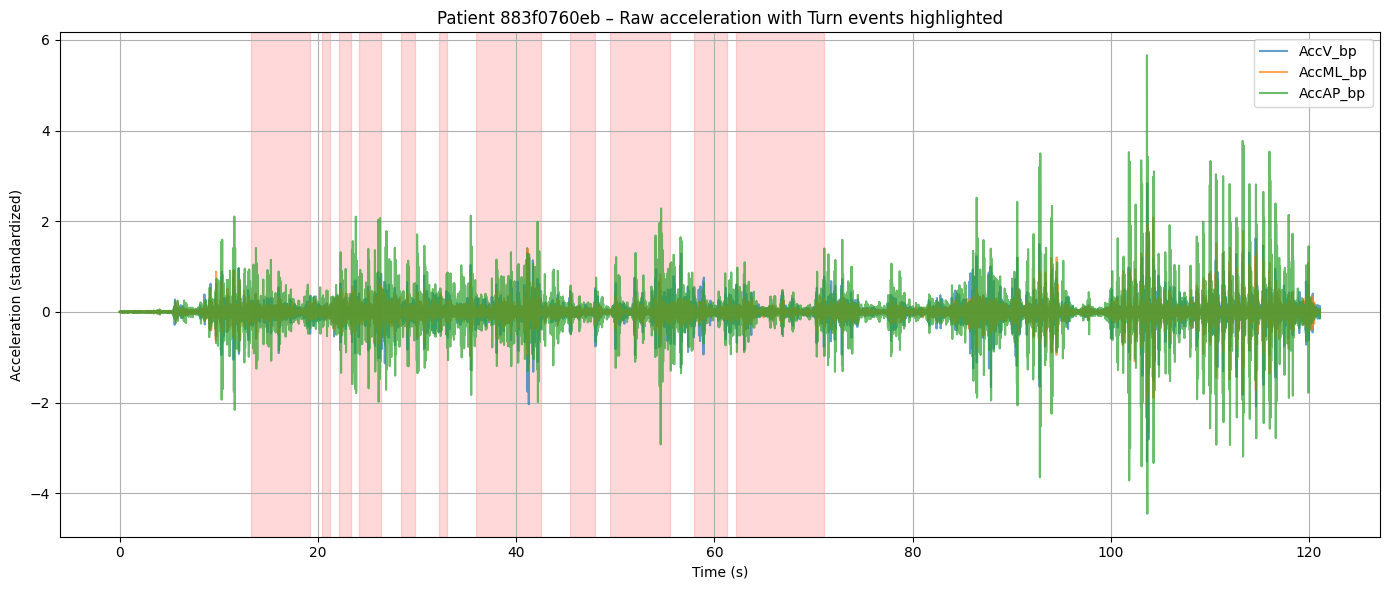

In [167]:
record_id = "883f0760eb"

# Get raw accelerometer signal for this patient (DEFOG)
df_sig = tdcsfog_df_bp.filter(pl.col("patient_id") == record_id).to_pandas()

# If Time is in samples, assume 100 Hz for DEFOG
FS_DEFOG = 100.0
time_sec = df_sig["Time"] / FS_DEFOG

# Use band pass columns 
sig_v  = "AccV_bp"  if "AccV_bp"  in df_sig.columns else "AccV"
sig_ml = "AccML_bp" if "AccML_bp" in df_sig.columns else "AccML"
sig_ap = "AccAP_bp" if "AccAP_bp" in df_sig.columns else "AccAP"

# Use the events we already aligned (events_with_feats)
events_patient = events_with_feats.copy()

plt.figure(figsize=(14, 6))

# Plot the three axes
plt.plot(time_sec, df_sig[sig_v],  label=sig_v,  alpha=0.7)
plt.plot(time_sec, df_sig[sig_ml], label=sig_ml, alpha=0.7)
plt.plot(time_sec, df_sig[sig_ap], label=sig_ap, alpha=0.7)

# Mark each event as a shaded region
for _, row in events_patient.iterrows():
    plt.axvspan(row["event_start_s"], row["event_end_s"],
                color="red", alpha=0.15)

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (standardized)")
plt.title(f"Patient {record_id} – Raw acceleration with Turn events highlighted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot spectogram around the events 

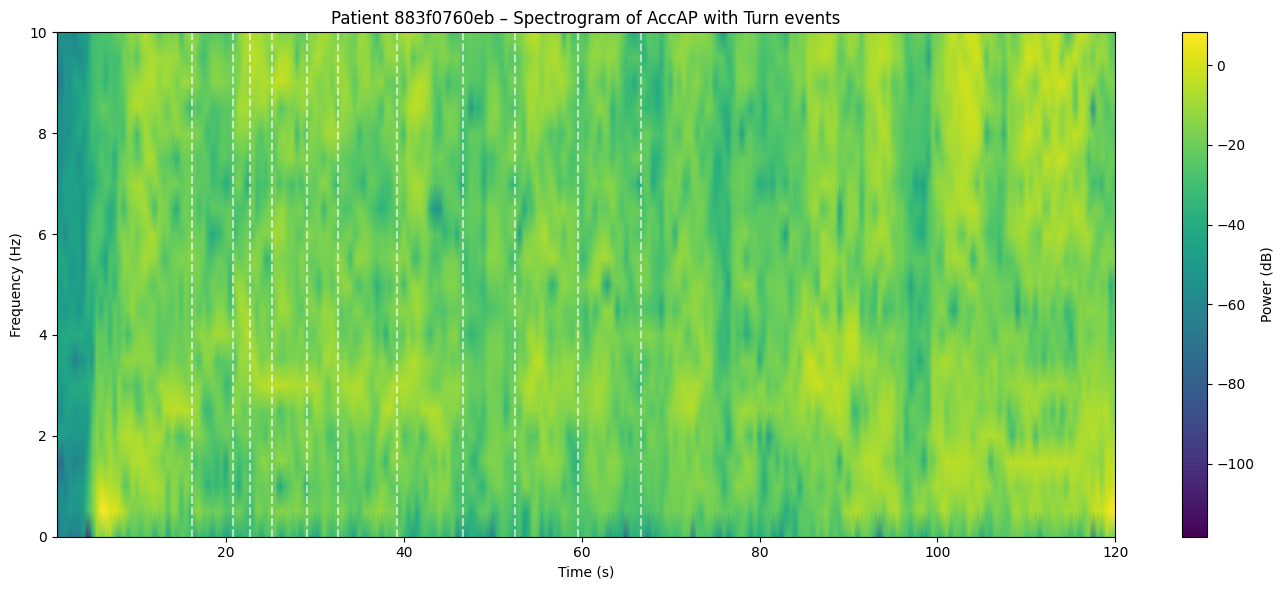

In [50]:
from scipy.signal import spectrogram

record_id = "883f0760eb"
df_sig = defog_df.filter(pl.col("patient_id") == record_id).to_pandas()

FS_DEFOG = 100.0
time_sec = df_sig["Time"] / FS_DEFOG

# Choose a signal: band-passed if you have it, else raw
if "AccAP_bp" in df_sig.columns:
    y = df_sig["AccAP_bp"].to_numpy()
else:
    y = df_sig["AccAP"].to_numpy()

# Compute spectrogram: 2-second windows, 75% overlap
nperseg = int(FS_DEFOG * 2.0)
noverlap = int(nperseg * 0.75)

f, t_spec, Sxx = spectrogram(
    y,
    fs=FS_DEFOG,
    nperseg=nperseg,
    noverlap=noverlap
)

plt.figure(figsize=(14, 6))
plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx + 1e-12), shading="gouraud")
plt.colorbar(label="Power (dB)")
plt.ylim(0, 10)  # 0–10 Hz is where gait & freezing live

# overlay event midpoints
for _, row in events_with_feats.iterrows():
    plt.axvline(row["event_mid_s"], color="white", linestyle="--", alpha=0.6)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"Patient {record_id} – Spectrogram of AccAP with Turn events")
plt.tight_layout()
plt.show()

In [51]:
# FS = 128.0
# WIN = 2.0
# HOP = 0.5

# # Manual frequency-domain features
# freq_feats = extract_frequency_features(
#     tdcsfog_df,
#     fs=FS,
#     win_s=WIN,
#     hop_s=HOP,
#     signal_cols=('AccV','AccML','AccAP')
# )

# freq_feats["t_center_s"] = (freq_feats["t_start_s"] + freq_feats["t_end_s"]) / 2
# tsfresh_feats["t_center_s"] = tsfresh_feats.index * WIN  # each window midpoint

# # Sort both by time before merge
# freq_feats = freq_feats.sort_values("t_center_s")
# tsfresh_feats = tsfresh_feats.sort_values("t_center_s")

# # Time-based merge — manual (left) → tsfresh (right)
# features_df = pd.merge_asof(
#     freq_feats,
#     tsfresh_feats,
#     on="t_center_s",
#     direction="nearest",
#     tolerance=0.5
# )

# print("Combined (time-aligned) feature set shape:", features_df.shape)

# Mutual Information Feature Selection 
- The MI between two quantities is a measure of the extent to which knowledge of one quantity reduces uncertainty about the other.
- MI is similar to correlation, but with the advantage of being able to detect any kind of relationship, not just linear ones. Moreover, it is easy to use and interpret, computationally

In [52]:
# Import mutual info selection libraries
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.cluster import KMeans 
import random

## 1. Create 'Target' Multi-class Label
- Create a single, multi-class target column called target from three binary event columns (expected for mutual info)
- For each event column (e.g. "StartHesitation"):
  - Find all rows where that event column is 1
    - Set their new 'target' value to the name of the event (e.g. "StartHesitation")
  - Otherwise, if event column is 0
    - Set their new 'target' value to "Normal"

In [53]:
# Build a multiclass target column
feats = tdcsfog_feats.with_columns(
    pl.when(pl.col("label_StartHesitation"))
      .then(pl.lit("StartHesitation"))
      .when(pl.col("label_Turn"))
      .then(pl.lit("Turn"))
      .when(pl.col("label_Walking"))
      .then(pl.lit("Walking"))
      .otherwise(pl.lit("Normal"))
      .alias("target")
)

## 2. Split into Train / Validation / Test 
- Split by continuous blocks (windows)
- train_df = Used to train the model (70%)
- val_df = Used to tune hyperparameters and prevent overfitting (15%)
- test_df = Used to evaluate final performance (15%)

In [54]:
# Assign block IDs based on win_id
BLOCK_SIZE = 1000  # ≈ 1000 * hop_s seconds per block (adjust to ~30–60 s if needed)
feats = feats.with_columns((pl.col("win_id") // BLOCK_SIZE).alias("block_id"))

# Split by block to keep contiguous sections together
blocks = feats.select("block_id").unique().to_series().to_list()
rng = random.Random(0); rng.shuffle(blocks)
n = len(blocks)
n_train = int(0.7 * n)
n_val   = int(0.15 * n)
b_train = set(blocks[:n_train])
b_val   = set(blocks[n_train:n_train+n_val])
b_test  = set(blocks[n_train+n_val:])

df_train = feats.filter(pl.col("block_id").is_in(b_train))
df_val   = feats.filter(pl.col("block_id").is_in(b_val))
df_test  = feats.filter(pl.col("block_id").is_in(b_test))

print(df_train.height, df_val.height, df_test.height)

76351 16000 18000


## 3. Fix Class Imbalance
- Fix class imbalance only on training dataset
- Use hybrid resampling 

In [55]:
# Class distribution 
df_train['target'].value_counts(normalize=True)

target,proportion
str,f64
"""Turn""",0.284174
"""Normal""",0.623973
"""StartHesitation""",0.054655
"""Walking""",0.037197


In [56]:
def hybrid_balance(df_train: pl.DataFrame, alpha: float = 2.0, seed: int = 0) -> pl.DataFrame:
    counts = df_train.group_by("target").agg(pl.len().alias("n"))
    classes = counts["target"].to_list()
    if "Normal" not in classes:
        return df_train

    minorities = counts.filter(pl.col("target") != "Normal")
    if minorities.is_empty():
        return df_train

    max_minority = int(minorities["n"].max())
    target_normal = int(alpha * max_minority)

    # Downsample Normal
    normal_blk = df_train.filter(pl.col("target") == "Normal")
    n_take = min(target_normal, normal_blk.height)
    if n_take < normal_blk.height:
        idx = np.random.RandomState(seed).choice(normal_blk.height, size=n_take, replace=False)
        normal_ds = normal_blk[idx.tolist()]  # slice by index list
    else:
        normal_ds = normal_blk

    # Upsample minorities
    parts = [normal_ds]
    turn_n = int(counts.filter(pl.col("target") == "Turn")["n"][0]) if "Turn" in classes else max_minority

    rng = np.random.RandomState(seed)
    for cls in ["Turn", "StartHesitation", "Walking"]:
        blk = df_train.filter(pl.col("target") == cls)
        if blk.is_empty():
            continue
        need = max(0, turn_n - blk.height)
        if need > 0:
            # random indices with replacement
            idx = rng.choice(blk.height, size=need, replace=True)
            blk_up = pl.concat([blk, blk[idx.tolist()]])
        else:
            blk_up = blk
        parts.append(blk_up)

    balanced = pl.concat(parts)

    # Manual shuffle by random permutation of row indices
    perm = np.random.RandomState(seed).permutation(balanced.height)
    balanced = balanced[perm.tolist()]

    return balanced


In [57]:
# View class balance after hybrid resampling 
df_train_bal = hybrid_balance(df_train, alpha=2.0, seed=0)
df_train_bal['target'].value_counts(normalize=True)

target,proportion
str,f64
"""Walking""",0.2
"""Turn""",0.2
"""Normal""",0.4
"""StartHesitation""",0.2


## 4. Encode the target 
- Target must be encoded because it is categorical

In [58]:
# Convert to pandas dataframe
df_train_pd = df_train_bal.to_pandas()

# Define features and target
target_col = "target"
feature_cols = [
    c for c in df_train_pd.columns
    if c not in [target_col, "t_start_s", "t_end_s", "win_id", "block_id"]
       and not c.startswith("label_")
]

X = df_train_pd[feature_cols]
y = df_train_pd[target_col]

In [59]:
# Encode target
le = LabelEncoder()
y_encode = le.fit_transform(y)

## 5. Compute & Visualize MI Scores

In [60]:
# Compute mutual info
mi = mutual_info_classif(X, y_encode, random_state=0)
mi_scores = pd.Series(mi, index=X.columns, name="MI Scores").sort_values(ascending=False)
print(mi_scores.head(20))

t_center_s      1.305929
AccAP_max       1.042570
AccV_min        1.036844
AccML_min       1.027850
AccV_max        1.027328
AccAP_min       1.023778
AccML_max       1.019696
AccAP_median    0.749281
AccAP_mean      0.740914
Acc_mag_mean    0.716347
AccV_median     0.711378
AccML_iqr       0.711274
Acc_sma         0.707247
AccV_iqr        0.706890
AccML_var       0.705754
AccML_std       0.705750
AccAP_iqr       0.705679
AccV_mean       0.705308
AccV_var        0.703431
AccV_std        0.703420
Name: MI Scores, dtype: float64


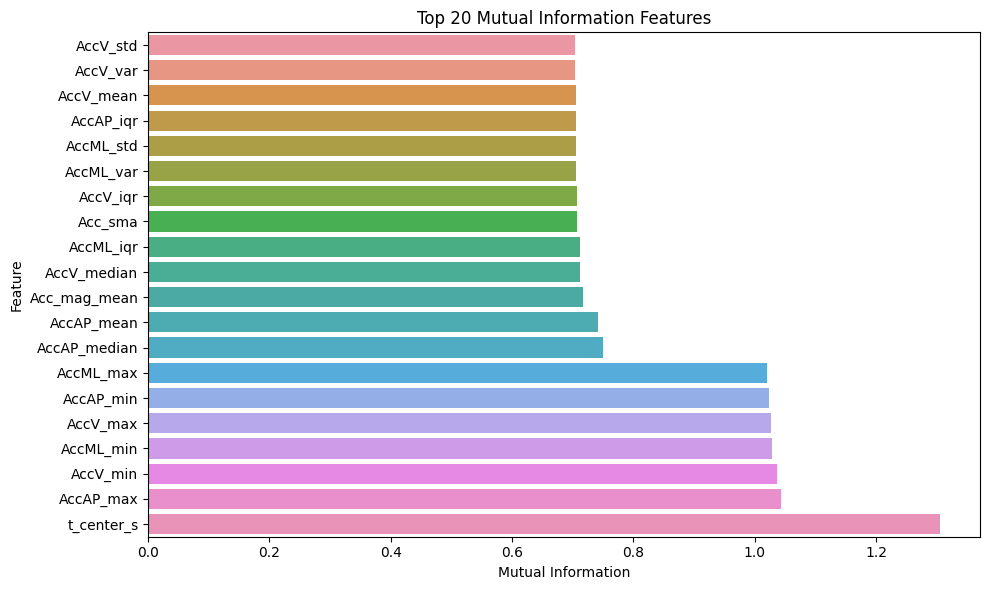

In [61]:
# Plot top-K MI features with Seaborn
TOP_K = 20
plt.figure(figsize=(10, 6))
topk = mi_scores.head(TOP_K).iloc[::-1] 
sns.barplot(x=topk.values, y=topk.index)
plt.title(f"Top {TOP_K} Mutual Information Features")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [62]:
print(mi_scores.tail(20))

AccV_skew           0.702855
AccAP_rms           0.702446
AccAP_energy        0.702434
AccAP_std           0.698983
AccAP_var           0.698982
Acc_mag_std         0.697981
AccML_median        0.696789
AccML_kurt          0.692238
AccAP_kurt          0.690307
corr_AccV_AccAP     0.690030
AccML_mean          0.686834
AccML_energy        0.685687
AccML_rms           0.685684
AccV_rms            0.685249
AccV_energy         0.685228
corr_AccV_AccML     0.685028
corr_AccML_AccAP    0.682116
AccV_kurt           0.680883
AccML_skew          0.677175
AccAP_skew          0.675398
Name: MI Scores, dtype: float64


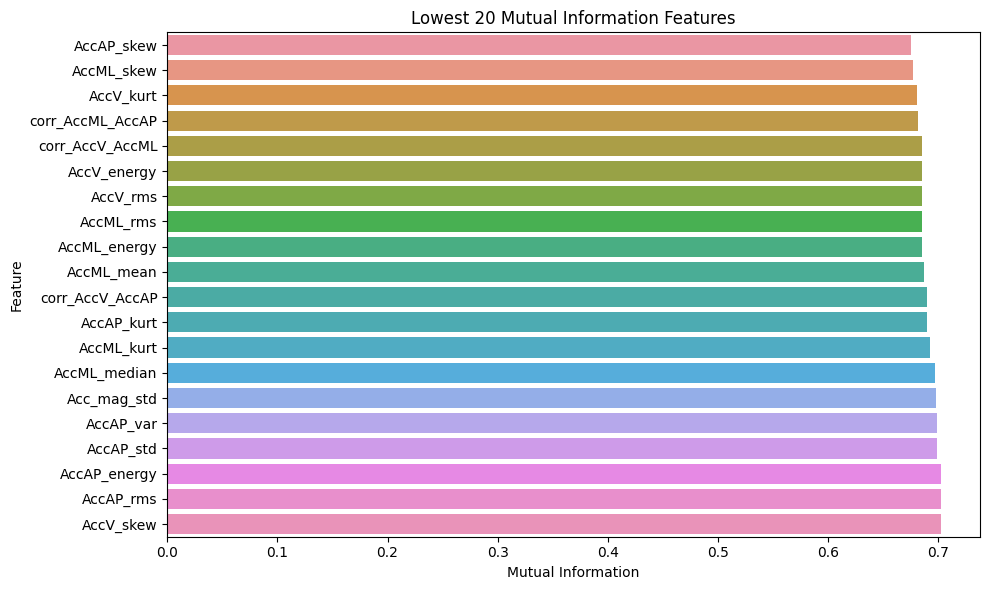

In [63]:
# Plot bottom 20 MI features 
BOTTOM_K = 20
plt.figure(figsize=(10, 6))
bottomk = mi_scores.tail(BOTTOM_K).iloc[::-1]
sns.barplot(x=bottomk.values, y=bottomk.index)
plt.title(f"Lowest {BOTTOM_K} Mutual Information Features")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### PCA & LDA Analysis

In [64]:
# # === TOP FIX CELL — Cleaned CSV path first ===
# # Set CLEANED_CSV to the path of your cleaned table (uploaded as a Kaggle Dataset via "Add data").
# # Example: CLEANED_CSV = "/kaggle/input/my-cleaned-dataset/cleaned.csv"
# # Optionally, if you already have a DataFrame in memory, set DF_NAME = "df_clean" as a fallback.

# from pathlib import Path
# import re, numpy as np, pandas as pd

# # >>>>>>>>>>>>>>>> REQUIRED: set your cleaned CSV path here <<<<<<<<<<<<<<<<
# CLEANED_CSV = "/kaggle/input/REPLACE_WITH_YOUR_DATASET/cleaned.csv"   # <-- CHANGE THIS
# # Optional fallback if you already have a DataFrame variable in memory:
# DF_NAME = None   # e.g., "df_clean"

# # For textual event labels mapping (if your label is text like "FOG/Turn/...")
# POSITIVE_LABELS = {"fog","freezing","turn","starthesitation"}

# def _detect_df_in_memory(df_name=None):
#     if df_name is not None:
#         if df_name in globals() and isinstance(globals()[df_name], pd.DataFrame):
#             return globals()[df_name]
#         raise RuntimeError(f"DF_NAME='{df_name}' not found as a pandas DataFrame.")
#     cands = [(k, v.shape[0]*v.shape[1], v) for k, v in globals().items() if isinstance(v, pd.DataFrame)]
#     if not cands:
#         return None
#     cands.sort(key=lambda x: x[1], reverse=True)
#     return cands[0][2]

# WORK_DF = None
# LABEL_COLUMN = None

# # (A) Cleaned CSV
# if CLEANED_CSV and Path(CLEANED_CSV).exists():
#     print("[INFO] Loading cleaned CSV:", CLEANED_CSV)
#     WORK_DF = pd.read_csv(CLEANED_CSV)
# else:
#     print("[WARN] CLEANED_CSV not found:", CLEANED_CSV)

# # (B) Fallback: in-memory DataFrame
# if WORK_DF is None:
#     mem_df = _detect_df_in_memory(DF_NAME)
#     if mem_df is not None:
#         WORK_DF = mem_df.copy()
#         print("[INFO] Using in-memory DataFrame. shape:", WORK_DF.shape)

# if WORK_DF is None or len(WORK_DF) == 0:
#     raise RuntimeError(
#         "No data found. Fix one of: (1) Set CLEANED_CSV to your uploaded cleaned table path; "
#         "(2) Set DF_NAME to your in-memory DataFrame name."
#     )

# # Auto-pick a plausible label column if present
# for c in WORK_DF.columns:
#     if c.lower() in ["is_fog","label","target","diagnosis","event","y","outcome"]:
#         LABEL_COLUMN = c
#         break

# print("[INFO] READY — WORK_DF shape:", WORK_DF.shape, "| LABEL_COLUMN:", LABEL_COLUMN)


# Training XGBoost Model 


1. Clean Dataset 

In [65]:
# df = events_with_feats_all.copy()

# df["label_bin"] = df["Type"].apply(lambda x: 1 if x == "Turn" else 0)

# X = df.drop(columns=["Id", "Type", "label_bin"])
# y = df["label_bin"]

In [66]:
df = events_with_feats_all.copy()

df["label_bin"] = df["Type"].apply(lambda x: 1 if x == "Turn" else 0)

# Drop non-feature columns
X = df.drop(columns=["Id", "Type", "label_bin", "patient_id"])
y = df["label_bin"]

In [67]:
# Remove all label-related columns (they are non-numeric)
bad_cols = [c for c in X.columns if c.startswith("label_")] + ["label_any"]

X = X.drop(columns=bad_cols, errors="ignore")

# Verify all remaining columns are numeric
print("Remaining non-numeric columns:", X.select_dtypes(exclude=["number"]).columns)

Remaining non-numeric columns: Index([], dtype='object')


2. Target Label 

In [68]:
# df = events_with_feats_all.copy()

# df["label_bin"] = df["Type"].apply(lambda x: 1 if x == "Turn" else 0)

# X = df.drop(columns=["Id", "Type", "label_bin"])
# y = df["label_bin"]

3. Train/Test Split 

In [69]:
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y_encoded, test_size=0.25, random_state=42, shuffle=True
# )

# print("Train size:", X_train.shape)
# print("Test size:", X_test.shape)

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42,
    shuffle=True,
    stratify=y          
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

print("y_train unique:", np.unique(y_train))
print("y_test unique:", np.unique(y_test))
print("Counts in y_train:", np.bincount(y_train))

Train size: (903, 115)
Test size: (302, 115)
y_train unique: [0 1]
y_test unique: [0 1]
Counts in y_train: [156 747]


In [71]:
# print("y_train unique:", np.unique(y_train))
# print("y_test unique:", np.unique(y_test))
# print("Counts in y_train:", np.bincount(y_train))

4. XGBoost Model 

In [72]:
# model = XGBClassifier(
#     n_estimators=200,
#     max_depth=4,
#    learning_rate=0.05,
#    subsample=0.8,
#    colsample_bytree=0.8,
#    objective="binary:logistic",
#    eval_metric="logloss",
#    tree_method="hist"
# )

# model.fit(X_train, y_train)

# print("Accuracy:", accuracy_score(y_test, y_pred))
# print(classification_report(y_test, y_pred))

In [73]:
# print("\nAccuracy:", accuracy_score(y_test, y_pred))
# print("\nClassification Report:")
# print(classification_report(
#     y_test, y_pred,
#     target_names=["Turn", "NotTurn"],
#    zero_division=0
# ))

In [74]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    scale_pos_weight = 156 / 747   # imbalance fix 
)

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [75]:
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["NotTurn", "Turn"],
    zero_division=0
))


Accuracy: 0.8774834437086093

Classification Report:
              precision    recall  f1-score   support

     NotTurn       0.67      0.58      0.62        52
        Turn       0.91      0.94      0.93       250

    accuracy                           0.88       302
   macro avg       0.79      0.76      0.77       302
weighted avg       0.87      0.88      0.87       302



Confusion Matrix Heatmap 

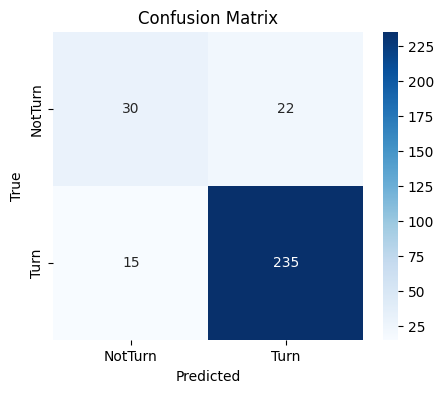

In [76]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NotTurn","Turn"],
            yticklabels=["NotTurn","Turn"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Feature Imporance Plot (XGBoost Built In) 

<Figure size 1200x800 with 0 Axes>

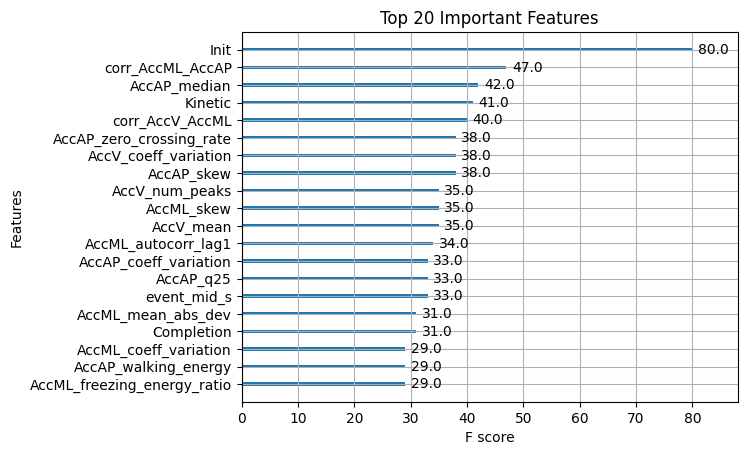

In [77]:
from xgboost import plot_importance

plt.figure(figsize=(12,8))
plot_importance(model, max_num_features=20)
plt.title("Top 20 Important Features")
plt.show()